# 004. 正規化と活性化の系譜

**層正規化・RMSNorm と ReLU・GELU・SwiGLU — 除去実験と合成タスクによる機構の切り分け**
*From Layer Normalization to RMSNorm, and from ReLU through GELU to SwiGLU*

`theories/01_foundations/004_normalization_and_activation.ipynb`

## 1. 概要 / Overview

[002](./002_transformer_block.ipynb) でスクラッチ実装した層正規化(Layer Normalization)は、平均減算(re-centering)と分散除算(re-scaling)の 2 つの操作から成る。RMSNorm(Root Mean Square Normalization、二乗平均平方根正規化)[2] は、このうち平均減算を省略し分散除算のみを行う簡略版であり、現代の大規模言語モデルの多くが層正規化の代わりに採用している。同様に、順伝播ネットワーク(Feed-Forward Network)の活性化関数も ReLU から GELU(Gaussian Error Linear Unit)[3] を経て、GLU(Gated Linear Unit)[5] 系のゲート機構を組み込んだ SwiGLU [6] へと発展してきた。

本ノートブックは、これらの変遷を「性能が上がったから」で済ませず、**何が本質的な変化で、何がそうでないか** を除去実験(ablation)・不変性の数値検証・小規模合成タスクによって切り分けることを目的とする。特に、文字レベル言語モデリングという 1 つの最終指標だけに頼らず、複数の実験を機構ごとに独立させることで、「効果があった」ことと「その機構が寄与した」ことを混同しないように設計する。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Ba, J., Kiros, J. R., Hinton, G. E. | Layer Normalization | arXiv:1607.06450, 2016 | https://arxiv.org/abs/1607.06450 |
| [2] | Zhang, B., Sennrich, R. | Root Mean Square Layer Normalization | NeurIPS 2019 | https://arxiv.org/abs/1910.07467 |
| [3] | Hendrycks, D., Gimpel, K. | Gaussian Error Linear Units (GELUs) | arXiv:1606.08415, 2016 | https://arxiv.org/abs/1606.08415 |
| [4] | Ramachandran, P., Zoph, B., Le, Q. V. | Searching for Activation Functions | arXiv:1710.05941, 2017 | https://arxiv.org/abs/1710.05941 |
| [5] | Dauphin, Y. N., Fan, A., Auli, M., Grangier, D. | Language Modeling with Gated Convolutional Networks | ICML 2017 | https://arxiv.org/abs/1612.08083 |
| [6] | Shazeer, N. | GLU Variants Improve Transformer | arXiv:2002.05202, 2020 | https://arxiv.org/abs/2002.05202 |
| [7] | Narang, S. et al. | Do Transformer Modifications Transfer Across Implementations and Applications? | EMNLP 2021 | https://arxiv.org/abs/2102.11972 |
| [8] | Touvron, H. et al. | LLaMA: Open and Efficient Foundation Language Models | arXiv:2302.13971, 2023 | https://arxiv.org/abs/2302.13971 |

[2] が正規化パート、[6] が活性化パートの原典である。[7] は、小規模な比較実験ではアーキテクチャ変更の優劣が観測できないことがある、という本ノートブックの結論の枠づけの根拠として使う。[8] は、現代の大規模言語モデルが RMSNorm と SwiGLU を実際に採用している例として、7 節末尾で参照する。

## 3. 理論 / Theory

**表記の約束**: 本ノートブックでは 002 と同様に、系列中の 1 トークンの隠れ状態を行ベクトル $a \in \mathbb{R}^{d_{\text{model}}}$ として扱う($d_{\text{model}}$: モデルの隠れ次元)。正規化・活性化はいずれもトークンごと・チャネル方向(特徴次元方向)に独立に作用するため、以下の数式はバッチ・系列長の次元を省略し 1 ベクトル $a$ に対する定義として記述する。

### 3.1 層正規化(Layer Normalization)の復習と一般形

[002](./002_transformer_block.ipynb) で導入した層正規化(Ba et al. [1])は、

$$
\mu = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} a_i, \qquad
\sigma^2 = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} (a_i - \mu)^2
$$

$$
\mathrm{LayerNorm}(a) = \gamma \odot \frac{a - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta
$$

と定義される。ここで $\gamma, \beta \in \mathbb{R}^{d_{\text{model}}}$ は学習可能なパラメータ、$\varepsilon$ は分散がゼロに近いときの数値安定化のための微小定数、$\odot$ は要素ごとの積である。

この定義は 2 つの独立した操作の合成として読み直せる。

1. **平均減算(re-centering)**: $a \mapsto a - \mu$。各成分から平均を引き、平均を 0 にそろえる。
2. **分散除算(re-scaling)**: $a \mapsto a / \sqrt{\sigma^2 + \varepsilon}$。標準偏差で割り、分散を 1 にそろえる。

`src/layers/normalization.py`(004 で拡張)の`LayerNormalization`は、この 2 つの操作をそれぞれ`center`・`scale`という bool 引数で独立に無効化できるようにしてある。4 通りの組み合わせ(いずれも $\gamma, \beta$ 自体は保持する)を実験 C で比較する。

### 3.2 RMSNorm(Root Mean Square Normalization、二乗平均平方根正規化)

RMSNorm(Zhang, Sennrich [2])は、層正規化から平均減算を落とし、分散除算のみを残した簡略版である。まず 2 乗平均平方根(RMS)を

$$
\mathrm{RMS}(a) = \sqrt{\frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} a_i^2}
$$

と定義すると、

$$
\mathrm{RMSNorm}(a) = \gamma \odot \frac{a}{\sqrt{\mathrm{RMS}(a)^2 + \varepsilon}}
$$

学習パラメータは $\gamma \in \mathbb{R}^{d_{\text{model}}}$ のみで、層正規化の $\beta$ に相当するシフトパラメータを持たない。

$\mathrm{RMS}(a)^2 = \frac{1}{d_{\text{model}}} \sum_i a_i^2$ は「平均 0 まわりの分散」ではなく「原点まわりの 2 乗平均」であることに注意する。もし $a$ がすでに平均 0 であれば($\mu = 0$)、$\mathrm{RMS}(a)^2 = \sigma^2$ となり、RMSNorm は層正規化から $\beta$ を除いたものと完全に一致する。この関係は、`LayerNormalization(center=False, scale=True)`と`RMSNorm`が初期化直後($\beta = 0$)に同じ出力を返すことに対応し、2 つの実装の相互検証として実験 B で確認する。

### 3.3 不変性の比較(平行移動不変性の喪失)

層正規化と RMSNorm の違いを、入力の変換に対する **不変性(invariance)** という観点から導出する。入力 $a$ に対して、スカラー $\alpha > 0$ とスカラー $b$ を用いた変換

$$
a \mapsto \alpha a + b \mathbf{1}, \qquad \mathbf{1} = (1, 1, \dots, 1) \in \mathbb{R}^{d_{\text{model}}}
$$

を考える(全成分を同じ倍率 $\alpha$ でスケールし、同じ量 $b$ だけシフトする)。以下、$\varepsilon \to 0$ の理想化した極限で考える($\varepsilon$ 自体は数値安定化のための項であり、不変性の議論の本質には影響しない)。

**層正規化は $\alpha$・$b$ の両方に不変である。** 変換後の平均・分散は $\mu' = \alpha \mu + b$、$\sigma'^2 = \alpha^2 \sigma^2$ となるため、

$$
\frac{(\alpha a_i + b) - \mu'}{\sqrt{\sigma'^2}} = \frac{\alpha (a_i - \mu)}{\alpha \sqrt{\sigma^2}} = \frac{a_i - \mu}{\sqrt{\sigma^2}}
$$

($\alpha > 0$ より $\sqrt{\alpha^2} = \alpha$)。$b$ は平均減算で厳密に打ち消され、$\alpha$ は分子・分母の両方に現れて厳密に打ち消される。

**RMSNorm は $\alpha$ にのみ不変で、$b$ には不変ではない。** 変換後の RMS は

$$
\mathrm{RMS}(\alpha a + b\mathbf{1})^2 = \frac{1}{d_{\text{model}}}\sum_i (\alpha a_i + b)^2 = \alpha^2 \mathrm{RMS}(a)^2 + 2\alpha b\,\bar{a} + b^2
$$

($\bar{a} = \mu$ は $a$ の平均)であり、$b \neq 0$ のとき $\mathrm{RMS}(\alpha a + b\mathbf{1})$ は $\mathrm{RMS}(a)$ の単純な定数倍にならない。したがって

$$
\mathrm{RMSNorm}(\alpha a + b\mathbf{1}) \neq \mathrm{RMSNorm}(\alpha a) = \mathrm{RMSNorm}(a) \quad (b \neq 0 \text{ のとき})
$$

($\alpha$ のみのスケーリング、$b=0$ の場合は $\mathrm{RMS}(\alpha a) = \alpha \,\mathrm{RMS}(a)$ となり厳密に不変)。

すなわち **RMSNorm は平行移動不変性(shift invariance)を失う**。この「失った性質」が実際の学習で問題になるかどうかは、理論だけでは決まらない実証的な問題である。実験 B で数値的に不変性の有無そのものを検証し、実験 D で実際の隠れ状態においてこの喪失が実害になっているかどうかを検証する。

### 3.4 演算回数とパラメータ数

$d_{\text{model}}$ 次元のベクトル 1 本を正規化するのに必要な演算回数(概算、定数個の演算は除く)とパラメータ数を比較する。

| | 加算・減算 | 乗算 | 除算 | 平方根 | パラメータ数 |
|---|---:|---:|---:|---:|---:|
| 層正規化(Layer Normalization) | $\approx 4 d_{\text{model}}$ | $\approx 2 d_{\text{model}}$ | $\approx 2 d_{\text{model}} + 1$ | $1$ | $2 d_{\text{model}}$($\gamma, \beta$) |
| RMSNorm | $\approx d_{\text{model}}$ | $\approx 2 d_{\text{model}}$ | $\approx d_{\text{model}} + 1$ | $1$ | $d_{\text{model}}$($\gamma$ のみ) |

RMSNorm は平均を計算する 1 パス($d_{\text{model}}$ 回の加算 + 中心化の $d_{\text{model}}$ 回の減算)と $\beta$ の加算($d_{\text{model}}$ 回)を省略できるため、層正規化よりおおむね加算・減算の回数が少なく、パラメータ数もちょうど半分になる。

> **注意: 本ノートブックでは実行時間の実測は行わない。** 理由は 2 つある。(1) [002](./002_transformer_block.ipynb) の実験でも述べた通り、Colab の共有 GPU 上での単一試行の計測はノイズが大きく、条件間の実行時間の差を主張する根拠にならない。(2) 正規化層はテンソル全体に対する演算量が小さく、演算密度(演算数 ÷ メモリアクセス量)が低いためメモリ帯域律速になりやすい。この場合、上表のような演算回数の削減がそのまま実測速度の改善に直結するとは限らない(この論点は 013 の Flash Attention でタイリングと合わせて再訪する)。したがって本ノートブックは演算回数・パラメータ数という理論値の比較に留め、実測時間による優劣は主張しない。

### 3.5 活性化関数: ReLU・GELU・Swish

**ReLU**: $\mathrm{ReLU}(x) = \max(0, x)$。原点で微分不可能、負領域で導関数が恒等的に 0 になる。

**GELU(Gaussian Error Linear Unit、Hendrycks, Gimpel [3])**: 標準正規分布(平均 0、分散 1)の累積分布関数(CDF)を $\Phi(x)$ として、

$$
\mathrm{GELU}(x) = x \, \Phi(x), \qquad \Phi(x) = \frac{1}{2}\left(1 + \mathrm{erf}\!\left(\frac{x}{\sqrt{2}}\right)\right)
$$

これが厳密形である($\mathrm{erf}$: 誤差関数)。計算コストの高い $\mathrm{erf}$ を避けるため、原論文は tanh を使った近似形も提示している。

$$
\mathrm{GELU}(x) \approx \frac{1}{2} x \left(1 + \tanh\!\left(\sqrt{\tfrac{2}{\pi}}\,(x + 0.044715\,x^3)\right)\right)
$$

**Swish / SiLU(Sigmoid Linear Unit、Ramachandran et al. [4])**: シグモイド関数 $\sigma(z) = 1/(1+e^{-z})$ を用いて、形状パラメータ $\beta$ を持つ

$$
\mathrm{Swish}_\beta(x) = x \, \sigma(\beta x)
$$

$\beta = 1$ のとき SiLU と呼ばれる形になる。$\beta \to \infty$ の極限で $\sigma(\beta x)$ はステップ関数(Heaviside 関数、$x<0$ で $0$、$x>0$ で $1$)に収束するため、

$$
\lim_{\beta \to \infty} \mathrm{Swish}_\beta(x) = x \cdot \mathbb{1}[x > 0] = \mathrm{ReLU}(x)
$$

すなわち **Swish は $\beta$ を介して ReLU を連続的に含む族になっている**。この収束の様子は実験 A で複数の $\beta$ について数値的に確認する。

### 3.6 GLU から SwiGLU へ

**GLU(Gated Linear Unit、Dauphin et al. [5])** は、線形変換の出力を別の線形変換にシグモイドを通した値で要素ごとに変調(ゲーティング)する機構である。

$$
\mathrm{GLU}(x, W, V, b, c) = (xW + b) \odot \sigma(xV + c)
$$

Shazeer [6] は、ゲート側の活性化関数 $\sigma$ を他の活性化関数に置き換えた一群の変種(ReGLU、GEGLU、SwiGLU など)を提案し、**SwiGLU** ではゲート側に Swish を使う。

$$
\mathrm{FFN}_{\text{SwiGLU}}(x) = \left(\mathrm{Swish}(x W) \odot x V\right) W_2
$$

ここで $W, V \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}'}$、$W_2 \in \mathbb{R}^{d_{\text{ff}}' \times d_{\text{model}}}$ であり($d_{\text{ff}}'$: SwiGLU の中間次元。標準の順伝播ネットワークの $d_{\text{ff}}$ と区別するためダッシュを付ける)、$\odot$ は要素ごとの積である。標準の順伝播ネットワーク(3.7 節で復習)が行列 2 つ($W_1, W_2$)なのに対し、SwiGLU は行列 3 つ($W, V, W_2$)を持つ。$\mathrm{Swish}(xW)$ が「$xV$ の各成分をどれだけ通すか」を決めるゲートとして働く。

### 3.7 パラメータ数を揃えるための中間次元の導出

[002](./002_transformer_block.ipynb) で実装した標準の順伝播ネットワーク(バイアスを省略して考える)は

$$
\mathrm{FFN}(x) = \mathrm{activation}(x W_1) W_2, \qquad W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}},\ W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}
$$

でパラメータ数は $2\, d_{\text{model}}\, d_{\text{ff}}$。一方 SwiGLU は行列を 3 つ持つため、中間次元を同じ $d_{\text{ff}}$ のまま置き換える(**素朴な置換**)と、パラメータ数は $3\, d_{\text{model}}\, d_{\text{ff}}$ となり **ちょうど 1.5 倍** に増える。

「ゲート機構そのものの寄与」と「単純にパラメータが増えたことによる寄与」を混同しないためには、パラメータ数を揃えた比較が必要になる。SwiGLU の中間次元を $d_{\text{ff}}'$ として、

$$
3\, d_{\text{model}}\, d_{\text{ff}}' = 2\, d_{\text{model}}\, d_{\text{ff}} \quad \Longrightarrow \quad d_{\text{ff}}' = \frac{2}{3}\, d_{\text{ff}}
$$

原論文([Vaswani et al., 2017])の設定 $d_{\text{ff}} = 4\, d_{\text{model}}$ を使うと、$d_{\text{ff}}' = \frac{8}{3}\, d_{\text{model}} \approx 2.667\, d_{\text{model}}$ となる(Shazeer [6] も同じ $\frac{2}{3}$ 倍の調整を採用している)。

$d_{\text{ff}}'$ は整数でなければならないため、実装では丸め込みが必要になる。本ノートブックの実験(共通ハイパーパラメータ: $d_{\text{model}} = 256$、$d_{\text{ff}} = 1024$)での実際の値を計算すると、

| | 中間次元 | 順伝播ネットワーク部分のパラメータ数 |
|---|---:|---:|
| 標準(GELU) | $d_{\text{ff}} = 1024$ | $2 \times 256 \times 1024 = 524{,}288$ |
| SwiGLU(パラメータ数を揃えた条件) | $d_{\text{ff}}' = \mathrm{round}(2/3 \times 1024) = 683$ | $3 \times 256 \times 683 = 524{,}544$ |
| SwiGLU(素朴な置換、中間次元そのまま) | $d_{\text{ff}} = 1024$ | $3 \times 256 \times 1024 = 786{,}432$($1.5$ 倍) |

丸め込みの結果、「パラメータ数を揃えた条件」も $524{,}544$ 対 $524{,}288$ で **256 個(約 0.05%)だけ厳密には一致していない**。この程度の差は無視できるが、「揃えた」という表現が近似であることは明記しておく。実験 E ではこの 2 つの SwiGLU 条件(揃えた条件・素朴な置換)の両方を比較し、素朴な置換だけでは「ゲートの寄与」と「パラメータ数の寄与」が交絡することを実験 G で機構レベルから、実験 E ではモデル全体のパラメータ数の観点から補強する。

### 3.8 図: 正規化の 4 条件・順伝播ネットワークのデータフロー・手法の系譜

以下は本ノートブックの構造を視覚的に整理するための Mermaid 図である。CLAUDE.md の方針により、**Google Colab やローカル Jupyter 上ではコードブロックのまま表示され図として描画されない**(GitHub 上のノートブックプレビューでは描画される)。そのため、以下の図がなくても 3.1〜3.7 節の数式・文章だけで理論が理解できるように書いてある。

**図 1: 正規化の 4 条件(平均減算 × 分散除算)**

```mermaid
graph TD
    subgraph SCALE["分散除算(re-scaling)あり"]
        A["center あり・scale あり<br/>= 層正規化 (Layer Normalization)<br/>実験 C 条件 1"]
        B["center なし・scale あり<br/>= RMSNorm と数学的に同じ計算<br/>実験 C 条件 2"]
    end
    subgraph NOSCALE["分散除算(re-scaling)なし"]
        C["center あり・scale なし<br/>= 平均減算のみ(陽性対照)<br/>実験 C 条件 3"]
        D["center なし・scale なし<br/>= 正規化なし、アフィン変換のみ(陽性対照)<br/>実験 C 条件 4"]
    end
```

**図 2: 標準の順伝播ネットワークと SwiGLU のデータフロー比較**

```mermaid
graph LR
    subgraph STD["標準の Feed-Forward Network(行列 2 本)"]
        x1["x"] --> W1["W_1"] --> ACT["activation(・)"] --> W2["W_2"] --> y1["出力"]
    end
    subgraph SWIGLU["SwiGLU(行列 3 本、要素ごとの積が 1 か所)"]
        x2["x"] --> W["W"] --> SW["Swish(・)"]
        x2 --> V["V"]
        SW --> MUL["⊙(要素ごとの積)"]
        V --> MUL
        MUL --> W2b["W_2"] --> y2["出力"]
    end
```

**図 3: 手法の系譜**

```mermaid
graph TD
    LN["層正規化<br/>Ba et al., 2016 [1]"] -->|"平均減算を省略"| RMS["RMSNorm<br/>Zhang & Sennrich, 2019 [2]"]
    ReLU["ReLU"] -->|"滑らかな近似"| GELU["GELU<br/>Hendrycks & Gimpel, 2016 [3]"]
    GLU["GLU<br/>Dauphin et al., 2017 [5]"] -->|"ゲートの活性化関数を Swish に"| SwiGLU["SwiGLU<br/>Shazeer, 2020 [6]"]
    GELU -.->|"Swish は GELU の近縁(3.5 節)"| SwiGLU
    RMS --> LLAMA["現代の大規模言語モデル<br/>例: LLaMA, 2023 [8]"]
    SwiGLU --> LLAMA
```

### 3.9 アルゴリズム / Algorithm

```text
RMSNorm(a, gamma, eps):
    ms  <- mean(a_i^2 for i in 1..d_model)      # RMS(a)^2
    a_hat <- a / sqrt(ms + eps)
    return gamma * a_hat                          # 要素ごとの積、beta は存在しない

FFN_SwiGLU(x, W, V, W2, beta):
    gate   <- Swish(x @ W, beta)                   # (..., d_ff')
    gated  <- gate * (x @ V)                        # 要素ごとの積、(..., d_ff')
    return gated @ W2                               # (..., d_model)
```

## 4. 実装方針 / Implementation Plan

**`src/`に切り出すもの**(理論的に本質的で、他トピック・`apps/`からも再利用する部品):

- 正規化層: `src/layers/normalization.py`に`LayerNormalization`(`center`・`scale`引数を追加)と`RMSNorm`を実装する。
- 活性化関数: `src/layers/activation.py`に`gelu_exact`・`gelu_tanh_approximation`・`swish`をスクラッチ実装する。
- 順伝播ネットワークの変種: `src/layers/feedforward.py`に`SwiGLUFeedForwardNetwork`を追加する。`FeedForwardNetwork`は活性化関数の指定方法を`activation_fn`(Callable)引数 1 つに一本化する(既定値`None`のとき ReLU、001・002・003 と同一の挙動)。
- ブロックへの注入点: `src/layers/transformer_block.py`の`EncoderBlock`・`DecoderBlock`に`normalization_factory`・`feed_forward_factory`・`activation_fn`を追加する。003 で`MultiHeadAttention`に位置エンコーディングを注入したのと同じ設計方針で、注入点がブロック内部にあるため、ラッパークラスを増やすのではなく optional 引数で拡張する。
- データ処理: `src/data/text.py`に文字レベルの`CharacterLevelTokenizer`と Tiny Shakespeare のロード関数を実装する。
- 測定関数: `src/utils/statistics.py`に、隠れ状態の平均/RMS 比・常に負のユニットの割合・ユニット群ごとの勾配ノルム・層ごとの勾配ノルムを計算する関数を実装する。
- 可視化: `src/utils/visualization.py`に、複数シードの散布図・層ごとの棒グラフ・関数曲線の描画関数を追加する。

**ノートブック内に直接書くもの**:

- 条件比較用の最小構成の言語モデル(`CausalCharacterLevelLanguageModel`、下記参照)と学習ループ。
- 実験ごとのデータ収集・統計量集計のグルーコード(隠れ状態やユニット活性化前の値を集めるための forward hook など)。
- 実験の実行・可視化コード。

**モデル本体と学習ループを`src/`に出さない理由**: 本格的な自己回帰言語モデリング(Autoregressive Language Modeling)の事前学習ループは 006(小型 GPT の事前学習)で扱う。004 の目的はあくまで正規化・活性化という **条件の比較** であり、汎用的な学習基盤の整備ではないため、比較に必要な最小構成のモデル・学習ループをこのノートブック内に閉じて実装する。

**decoder-only 構成の作り方**: 言語モデリングには、各トークンが自分より前のトークンだけを参照する decoder-only な自己回帰モデルが必要になる。002 の`DecoderBlock`は Encoder の出力(memory)を参照する交差注意(cross-attention)を持つため、そのままでは言語モデリングに使えない(memory が存在しない)。本ノートブックでは、**`EncoderBlock`に因果マスク(causal mask、`create_causal_mask()`)を渡すことで decoder-only 構成を作る**。`EncoderBlock`はもともと自己注意のみの 2 サブレイヤー構成であり、マスクを渡すだけで「各位置が自分より前しか見えない自己回帰モデル」になる。名前に反して「Encoder」を使うのは紛らわしいが、`DecoderBlock`という名前のクラスを使わないのが正しい選択であることを、誤解を避けるためにここで明示しておく。

**正規化の配置**: 002 の実験 2 の結論([002](./002_transformer_block.ipynb) 6.2 節)に従い、全条件で **正規化前置(Pre-Layer Normalization、`norm_first=True`)に固定** する。正規化前置・正規化後置の比較は 002 で既に扱っているため、004 では正規化そのものの中身(平均減算・分散除算の有無)の比較に集中する。

**評価データを固定する理由**: 学習ループの検証損失を、学習の各評価タイミングで`train_data`からランダムに引いた 1 バッチだけで計算すると、評価バッチ自体のサンプリングノイズが条件・シードごとに異なる形で最終検証損失に混入する。これは、6 節冒頭で定める「5 シードの最小値〜最大値の区間が重なるかどうか」という判定基準の信頼性を直接損なう(区間の重なりが、条件間の実質的な差ではなく評価ノイズによって生じている可能性を排除できない)。そこで、ノートブック上部で **評価用バッチの集合を独立した乱数生成器で 1 度だけ固定生成し、以降の全条件・全シードでこの同じ集合を使い回す**。これにより、最終検証損失の変動要因を「学習過程の違い(乱数シードと条件)」のみに限定できる。

**`CausalCharacterLevelLanguageModel`の設計**: `token_embedding`・学習可能な絶対位置埋め込み(`position_embedding`、[003](./003_positional_encoding_rope.ipynb)で導入した学習可能絶対位置埋め込みの最小版)・`EncoderBlock`を`n_layers`個積んだ`blocks`・最終正規化・出力射影(`lm_head`)から成る。`normalization_factory`・`feed_forward_factory`を`EncoderBlock`にそのまま透過させることで、正規化の種類(実験 C)と活性化・順伝播ネットワークの種類(実験 E)を、モデルの他の部分を変えずに差し替えられるようにする。

## 5. 実装 / Implementation

### 5.1 環境セットアップ

In [1]:
# 環境セットアップ(Google Colab)
# Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

In [2]:
# `from src...` の絶対 import が通るように、リポジトリルートを sys.path に追加する。
# (ノートブックを theories/01_foundations/ から直接開いた場合の保険)
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # theories/01_foundations/ から起動した場合
    ROOT = ROOT.parents[1]
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repository root:", ROOT)

repository root: /Users/koji/projects/ai-theories


In [3]:
import inspect
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from src.data import (
    CharacterLevelTokenizer,
    get_random_batch,
    load_tiny_shakespeare,
    split_train_val,
)
from src.layers import (
    EncoderBlock,
    FeedForwardNetwork,
    LayerNormalization,
    RMSNorm,
    SwiGLUFeedForwardNetwork,
    create_causal_mask,
    gelu_exact,
    gelu_tanh_approximation,
    swish,
)
from src.utils import (
    compute_always_negative_unit_ratio,
    compute_gradient_norm_by_unit_group,
    compute_gradient_norm_per_layer,
    compute_mean_to_rms_ratio,
    plot_bar_by_layer,
    plot_function_curves,
    plot_learning_curves,
    plot_seed_scatter,
)

# 再現性のためのシード固定
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"torch: {torch.__version__} / device: {device}")

torch: 2.13.0 / device: mps


### 5.2 正規化層の実装確認: `center`・`scale`と`RMSNorm`

`LayerNormalization`の`center=True, scale=True`(既定値)は 002 と完全に同一の計算になっていることを確認し、続けて`center=False, scale=True`(RMSNorm と数学的に同じ計算)が初期化直後(`beta=0`)に`RMSNorm`と一致することを確認する(これは実験 B でも扱う相互検証だが、実装確認の時点でも確かめておく)。

In [4]:
print(inspect.getsource(LayerNormalization.forward))

    def forward(self, x: Tensor) -> Tensor:
        """層正規化を適用する。

        Args:
            x: 形状 ``(..., d_model)`` の入力。

        Returns:
            x と同じ形状の正規化済みテンソル。
        """
        if self.center and self.scale:
            # center=True, scale=True(既定値)は 002 と完全に同一の計算にする。
            mean = x.mean(dim=-1, keepdim=True)
            # unbiased=False: 分散は 1/d_model の標本分散を使う(nn.LayerNorm と同じ規約)。
            var = x.var(dim=-1, keepdim=True, unbiased=False)
            x_hat = (x - mean) / torch.sqrt(var + self.eps)
            return self.gamma * x_hat + self.beta

        x_hat = x
        if self.center:
            x_hat = x_hat - x_hat.mean(dim=-1, keepdim=True)
        if self.scale:
            # center=False の場合、x_hat = x に対する 2 乗平均(平均減算前の分散)になる。
            mean_square = x_hat.pow(2).mean(dim=-1, keepdim=True)
            x_hat = x_hat / torch.sqrt(mean_square + self.eps)
        return self.gamma * x_hat + self.beta



In [5]:
torch.manual_seed(SEED)
D_MODEL_CHECK = 32
x_check = torch.randn(4, 6, D_MODEL_CHECK)

ln_default = LayerNormalization(D_MODEL_CHECK)
mean = x_check.mean(dim=-1, keepdim=True)
var = x_check.var(dim=-1, keepdim=True, unbiased=False)
expected = (x_check - mean) / torch.sqrt(var + ln_default.eps)
print(
    "LayerNormalization(既定値)が手計算と一致:",
    torch.allclose(ln_default(x_check), expected, atol=1e-6),
)

ln_scale_only = LayerNormalization(D_MODEL_CHECK, center=False, scale=True)
rms_check = RMSNorm(D_MODEL_CHECK)
print(
    "center=False, scale=True と RMSNorm が初期化直後に一致:",
    torch.allclose(ln_scale_only(x_check), rms_check(x_check), atol=1e-6),
)

for center, scale, label in [
    (True, True, "層正規化(center=True, scale=True)"),
    (False, True, "分散除算のみ(center=False, scale=True)"),
    (True, False, "平均減算のみ(center=True, scale=False)"),
    (False, False, "正規化なし(center=False, scale=False)"),
]:
    m = LayerNormalization(D_MODEL_CHECK, center=center, scale=scale)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {label:38s}: パラメータ数 = {n_params}(4 条件とも d_model の 2 倍で共通)")

LayerNormalization(既定値)が手計算と一致: True
center=False, scale=True と RMSNorm が初期化直後に一致: True
  層正規化(center=True, scale=True)         : パラメータ数 = 64(4 条件とも d_model の 2 倍で共通)
  分散除算のみ(center=False, scale=True)      : パラメータ数 = 64(4 条件とも d_model の 2 倍で共通)
  平均減算のみ(center=True, scale=False)      : パラメータ数 = 64(4 条件とも d_model の 2 倍で共通)
  正規化なし(center=False, scale=False)      : パラメータ数 = 64(4 条件とも d_model の 2 倍で共通)


### 5.3 活性化関数の実装確認: スクラッチ実装と`torch.nn.functional`の数値一致

CLAUDE.md の方針に従い、GELU・Swish は`torch.nn.functional`を使わずスクラッチ実装した(`src/layers/activation.py`)。正しさの確認として、対応する組み込み実装との最大絶対誤差を計測する。

In [6]:
x_act = torch.linspace(-6.0, 6.0, 2001)

diff_gelu_exact = (gelu_exact(x_act) - F.gelu(x_act)).abs().max().item()
diff_gelu_tanh = (
    (gelu_tanh_approximation(x_act) - F.gelu(x_act, approximate="tanh")).abs().max().item()
)
diff_swish = (swish(x_act, beta=1.0) - F.silu(x_act)).abs().max().item()
diff_gelu_exact_vs_tanh = (gelu_exact(x_act) - gelu_tanh_approximation(x_act)).abs().max().item()

print(f"gelu_exact            vs F.gelu                    最大絶対誤差: {diff_gelu_exact:.3e}")
print(f"gelu_tanh_approximation vs F.gelu(approximate=tanh) 最大絶対誤差: {diff_gelu_tanh:.3e}")
print(f"swish(beta=1)          vs F.silu                    最大絶対誤差: {diff_swish:.3e}")
print(
    f"gelu_exact             vs gelu_tanh_approximation    "
    f"最大絶対誤差: {diff_gelu_exact_vs_tanh:.3e}"
)

gelu_exact            vs F.gelu                    最大絶対誤差: 2.384e-07
gelu_tanh_approximation vs F.gelu(approximate=tanh) 最大絶対誤差: 0.000e+00
swish(beta=1)          vs F.silu                    最大絶対誤差: 4.768e-07
gelu_exact             vs gelu_tanh_approximation    最大絶対誤差: 4.734e-04


### 5.4 順伝播ネットワークの変種の実装確認: `SwiGLUFeedForwardNetwork`

3.7 節で導出したパラメータ数を揃える中間次元 $d_{\text{ff}}' = \mathrm{round}(2/3 \times d_{\text{ff}})$ を、共通ハイパーパラメータ($d_{\text{model}}=256$、$d_{\text{ff}}=1024$)で実際に計算し、理論値どおりのパラメータ数になっていることを確認する。`FeedForwardNetwork`は`activation_fn`(Callable)引数に一本化してあるため(004 で、文字列引数との併存を解消)、GELU を使いたい場合は`activation_fn=gelu_exact`を渡す(既定値`None`は ReLU、001・002・003 と同一の挙動)。

In [7]:
D_MODEL_COMMON, N_LAYERS_COMMON, N_HEADS_COMMON, D_FF_COMMON, SEQ_LEN_COMMON = 256, 4, 4, 1024, 128
D_FF_SWIGLU_MATCHED = round((2 / 3) * D_FF_COMMON)

feed_forward_standard = FeedForwardNetwork(D_MODEL_COMMON, D_FF_COMMON, activation_fn=gelu_exact)
feed_forward_swiglu_matched = SwiGLUFeedForwardNetwork(D_MODEL_COMMON, D_FF_SWIGLU_MATCHED)
feed_forward_swiglu_naive = SwiGLUFeedForwardNetwork(D_MODEL_COMMON, D_FF_COMMON)

n_standard = sum(p.numel() for p in feed_forward_standard.parameters())
n_matched = sum(p.numel() for p in feed_forward_swiglu_matched.parameters())
n_naive = sum(p.numel() for p in feed_forward_swiglu_naive.parameters())

print(f"標準(GELU, d_ff={D_FF_COMMON})                             パラメータ数: {n_standard:,}")
print(
    f"SwiGLU(パラメータ数を揃えた条件, d_ff'={D_FF_SWIGLU_MATCHED})   パラメータ数: {n_matched:,}"
)
print(
    f"SwiGLU(素朴な置換, d_ff={D_FF_COMMON})                       "
    f"パラメータ数: {n_naive:,}({n_naive / n_standard:.3f} 倍)"
)

x_feed_forward_check = torch.randn(2, 5, D_MODEL_COMMON)
print("SwiGLU 出力形状:", tuple(feed_forward_swiglu_matched(x_feed_forward_check).shape))

標準(GELU, d_ff=1024)                             パラメータ数: 525,568
SwiGLU(パラメータ数を揃えた条件, d_ff'=683)   パラメータ数: 524,544
SwiGLU(素朴な置換, d_ff=1024)                       パラメータ数: 786,432(1.496 倍)
SwiGLU 出力形状: (2, 5, 256)


### 5.5 `EncoderBlock`への注入点の実装確認

`normalization_factory`・`feed_forward_factory`を指定しない場合、002・003 と完全に同じ`LayerNormalization` + `FeedForwardNetwork`(ReLU)が使われることを確認する。

In [8]:
torch.manual_seed(SEED)
encoder_block_default = EncoderBlock(D_MODEL_COMMON, N_HEADS_COMMON, D_FF_COMMON)
print("既定のnormalization:", type(encoder_block_default.norm1).__name__)
print("既定のfeed_forward:", type(encoder_block_default.feed_forward).__name__)
print("既定の活性化関数:", type(encoder_block_default.feed_forward.activation).__name__)

encoder_block_injected = EncoderBlock(
    D_MODEL_COMMON,
    N_HEADS_COMMON,
    D_FF_COMMON,
    normalization_factory=lambda d: RMSNorm(d),
    feed_forward_factory=lambda: SwiGLUFeedForwardNetwork(D_MODEL_COMMON, D_FF_SWIGLU_MATCHED),
)
print("注入後のnormalization:", type(encoder_block_injected.norm1).__name__)
print("注入後のfeed_forward:", type(encoder_block_injected.feed_forward).__name__)

x_block_check = torch.randn(2, SEQ_LEN_COMMON, D_MODEL_COMMON)
mask_block_check = create_causal_mask(SEQ_LEN_COMMON)
out_block_check, attn_block_check = encoder_block_injected(x_block_check, mask_block_check)
print("因果マスクつき EncoderBlock 出力形状:", tuple(out_block_check.shape))

既定のnormalization: LayerNormalization
既定のfeed_forward: FeedForwardNetwork
既定の活性化関数: ReLU
注入後のnormalization: RMSNorm
注入後のfeed_forward: SwiGLUFeedForwardNetwork
因果マスクつき EncoderBlock 出力形状: (2, 128, 256)


### 5.6 データ: Tiny Shakespeare の文字レベル分割

`src/data/text.py`の`CharacterLevelTokenizer`(文字単位の最小限の処理。サブワード分割は 005 で扱う)で、Andrej Karpathy の char-rnn リポジトリで配布されている Tiny Shakespeare データセットを文字 ID 列に変換し、学習用・検証用に分割する。

In [9]:
CACHE_DIR = ROOT / ".cache" / "tiny_shakespeare"
raw_text = load_tiny_shakespeare(CACHE_DIR)
print(f"テキスト長: {len(raw_text):,} 文字")
print(raw_text[:200])

テキスト長: 1,115,394 文字
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [10]:
tokenizer = CharacterLevelTokenizer(raw_text)
VOCAB_SIZE = tokenizer.vocab_size
print(f"語彙サイズ V = {VOCAB_SIZE}")

token_ids = tokenizer.encode(raw_text)
train_data, val_data = split_train_val(token_ids, val_ratio=0.1)
print(f"学習用: {len(train_data):,} 文字 / 検証用: {len(val_data):,} 文字")

# encode/decode の往復確認
sample_text = raw_text[:100]
assert tokenizer.decode(tokenizer.encode(sample_text)) == sample_text
print("encode -> decode の往復確認: OK")

x_batch_demo, y_batch_demo = get_random_batch(
    train_data, batch_size=4, seq_len=16, generator=torch.Generator().manual_seed(SEED)
)
print("バッチ形状 (inputs, targets):", tuple(x_batch_demo.shape), tuple(y_batch_demo.shape))
print("入力例:", repr(tokenizer.decode(x_batch_demo[0])))
print("targetは1つ右にずれている:", repr(tokenizer.decode(y_batch_demo[0])))

語彙サイズ V = 65
学習用: 1,003,855 文字 / 検証用: 111,539 文字
encode -> decode の往復確認: OK
バッチ形状 (inputs, targets): (4, 16) (4, 16)
入力例: '\nNot in a grave,'
targetは1つ右にずれている: 'Not in a grave,\n'


### 5.7 `CausalCharacterLevelLanguageModel`: 条件比較用の最小構成の言語モデル

4 節で述べた通り、本格的な事前学習ループは 006 で扱うため、ここでは条件比較に必要な最小構成のみを実装する。`normalization_factory`・`feed_forward_factory`を通じて、正規化・順伝播ネットワークの実装を差し替えられるようにしてある。`record_layer_outputs=True`を渡すと、各`EncoderBlock`の出力に`retain_grad()`を呼んで`self.layer_outputs`に記録する(実験 D で`compute_gradient_norm_per_layer()`と組み合わせて使う)。

In [11]:
class CausalCharacterLevelLanguageModel(nn.Module):
    """条件比較用の最小構成の decoder-only 文字レベル言語モデル。

    `EncoderBlock` に因果マスクを与えることで decoder-only 構成にする(4 節参照)。
    本格的な事前学習ループ(データローダの効率化、KV キャッシュ、学習率のチューニングなど)は
    006 で扱うため、本クラスは 004 の条件比較(正規化・活性化の差し替え)に
    必要な最小構成に留める。

    Args:
        vocab_size: 語彙サイズ V。
        d_model, n_layers, n_heads, d_ff: Transformer Block の次元・層数・ヘッド数・中間次元。
        seq_len: 学習可能絶対位置埋め込みが対応する最大系列長。
        normalization_factory: `EncoderBlock` にそのまま渡す正規化層の factory。
        feed_forward_factory: `EncoderBlock` にそのまま渡す順伝播ネットワークの factory。
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        n_layers: int,
        n_heads: int,
        d_ff: int,
        seq_len: int,
        normalization_factory=None,
        feed_forward_factory=None,
    ) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        self.blocks = nn.ModuleList(
            [
                EncoderBlock(
                    d_model,
                    n_heads,
                    d_ff,
                    normalization_factory=normalization_factory,
                    feed_forward_factory=feed_forward_factory,
                )
                for _ in range(n_layers)
            ]
        )
        norm_fn = normalization_factory or LayerNormalization
        self.final_norm = norm_fn(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: Tensor, record_layer_outputs: bool = False) -> Tensor:
        _, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device)
        hidden = self.token_embedding(input_ids) + self.position_embedding(positions)[None]
        mask = create_causal_mask(seq_len, device=input_ids.device)

        if record_layer_outputs:
            self.layer_outputs = []
        for block in self.blocks:
            hidden, _ = block(hidden, mask)
            if record_layer_outputs:
                hidden.retain_grad()
                self.layer_outputs.append(hidden)

        hidden = self.final_norm(hidden)
        return self.lm_head(hidden)


torch.manual_seed(SEED)
language_model_check = CausalCharacterLevelLanguageModel(VOCAB_SIZE, 32, 2, 4, 64, 16)
x_language_model_check = torch.randint(0, VOCAB_SIZE, (3, 16))
print(
    "CausalCharacterLevelLanguageModel 出力形状:",
    tuple(language_model_check(x_language_model_check).shape),
    "(期待値: (3, 16, V))",
)

CausalCharacterLevelLanguageModel 出力形状: (3, 16, 65) (期待値: (3, 16, V))


### 5.8 評価用バッチの固定(評価ノイズの除去)

4 節で述べた通り、最終検証損失に評価バッチのサンプリングノイズが混入しないよう、**評価用バッチの集合を独立した乱数生成器で 1 度だけ固定生成し、以降の全条件・全シードでこの同じ集合を使い回す**。評価は固定集合全体にわたるトークン数で重み付けした平均損失とする。

In [12]:
N_EVALUATION_BATCHES = 20
BATCH_SIZE_LANGUAGE_MODEL = 32

# 学習バッチの生成(条件・シードごとに異なる)とは独立した乱数生成器を使う。
evaluation_batch_generator = torch.Generator().manual_seed(12345)
evaluation_batches = [
    get_random_batch(
        val_data, BATCH_SIZE_LANGUAGE_MODEL, SEQ_LEN_COMMON, generator=evaluation_batch_generator
    )
    for _ in range(N_EVALUATION_BATCHES)
]
print(
    f"固定評価バッチ: {N_EVALUATION_BATCHES} バッチ "
    f"× {BATCH_SIZE_LANGUAGE_MODEL} × {SEQ_LEN_COMMON} "
    f"= {N_EVALUATION_BATCHES * BATCH_SIZE_LANGUAGE_MODEL * SEQ_LEN_COMMON:,} トークン"
)


# 固定評価バッチ集合全体にわたる、トークン数で重み付けした平均損失を計算する。
def evaluate_language_model(model: nn.Module, evaluation_batches, device: torch.device) -> float:
    model.eval()
    loss_fn = nn.CrossEntropyLoss(reduction="sum")
    total_loss_sum = 0.0
    total_tokens = 0
    with torch.no_grad():
        for inputs, targets in evaluation_batches:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            total_loss_sum += loss_fn(
                logits.reshape(-1, logits.size(-1)), targets.reshape(-1)
            ).item()
            total_tokens += targets.numel()
    return total_loss_sum / total_tokens

固定評価バッチ: 20 バッチ × 32 × 128 = 81,920 トークン


### 5.9 学習ループ

線形 warmup + cosine 減衰の学習率スケジュール、勾配クリッピングを備えた最小限の学習ループを実装する。損失が非有限(NaN / Inf)になった場合は打ち切り、`diverged=True`として発散した事実をそのまま記録する(実験 C の陽性対照条件で使う。ハイパーパラメータは条件によらず共通のものを使う)。検証損失の計算は 5.8 節で固定した`evaluation_batches`を使う。

In [13]:
def train_character_level_language_model(
    model: nn.Module,
    train_data: Tensor,
    evaluation_batches,
    steps: int,
    batch_size: int,
    seq_len: int,
    learning_rate: float,
    warmup_steps: int,
    seed: int,
    device: torch.device,
    evaluate_every: int = 50,
    grad_clip: float = 1.0,
) -> tuple[dict, bool]:
    """文字レベル言語モデルの最小限の学習ループ。

    Returns:
        (history, diverged) のタプル。history は {"step", "train_loss", "evaluation_loss"} を
        持つ辞書。diverged は損失が非有限になり途中で打ち切った場合に True。
    """
    torch.manual_seed(seed)
    batch_generator = torch.Generator().manual_seed(seed)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    loss_fn = nn.CrossEntropyLoss()
    history = {"step": [], "train_loss": [], "evaluation_loss": []}
    diverged = False

    for step in range(steps):
        inputs, targets = get_random_batch(
            train_data, batch_size, seq_len, generator=batch_generator
        )
        inputs, targets = inputs.to(device), targets.to(device)

        model.train()
        optimizer.zero_grad()
        logits = model(inputs)
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        if not torch.isfinite(loss):
            diverged = True
            history["step"].append(step)
            history["train_loss"].append(float("nan"))
            history["evaluation_loss"].append(float("nan"))
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()

        if step % evaluate_every == 0 or step == steps - 1:
            evaluation_loss = evaluate_language_model(model, evaluation_batches, device)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["evaluation_loss"].append(evaluation_loss)

    return history, diverged

## 6. 実験 / Experiments

> **実行環境について**: 以下の実験で報告する実測値は、本ノートブックをローカル環境(実行時の`device`変数の値を参照)で実行して得たものである。文字レベル言語モデリングの学習(実験 C・E)は、6.3 節の計測セルで実測した 1 step あたりの所要時間に安全係数を掛けたうえで、合計 35 run の目標時間から step 数を決定している(詳細は 6.3 節)。**本ノートブックを Google Colab の T4 GPU 上で改めて本実行することは別途必要であり、以下の数値・考察はその本実行前のローカル環境での完走確認(ドラフト)である。** 最終的な数値が入れ替わっている場合は、Colab T4 GPU での本実行結果への更新が未反映であることを意味する。

**判定基準(実験の実行前に定める)**: 複数シードを使う実験(実験 C・E・G)では、各条件を **5 個(実験 C・E)または 10 個(実験 G)の乱数シード(seed)** で実行し、平均・標準偏差に加えて **個々のシードの値をすべてプロットに重ねる**(`plot_seed_scatter`)。条件間で 5(または 10)シードの最小値〜最大値の区間が重なる場合、優劣を主張せず「この規模では差を検出できなかった」と記述する。この基準は実験の実行前に定めたものであり、結果を見てから閾値を調整することはしない。最終検証損失の計算には 5.8 節で固定した評価用バッチ集合を全条件・全シードで共通に使うため、評価バッチのサンプリングノイズはこの判定基準の信頼性を損なわない。

### 6.1 実験 A: 活性化関数の形状(学習不要)

ReLU・GELU(厳密形・tanh 近似形)・Swish(複数の$\beta$)の関数値と導関数を描画し、3.5 節の理論(GELU の 2 つの近似の一致度、Swish の$\beta \to \infty$での ReLU への収束)を数値で確認する。

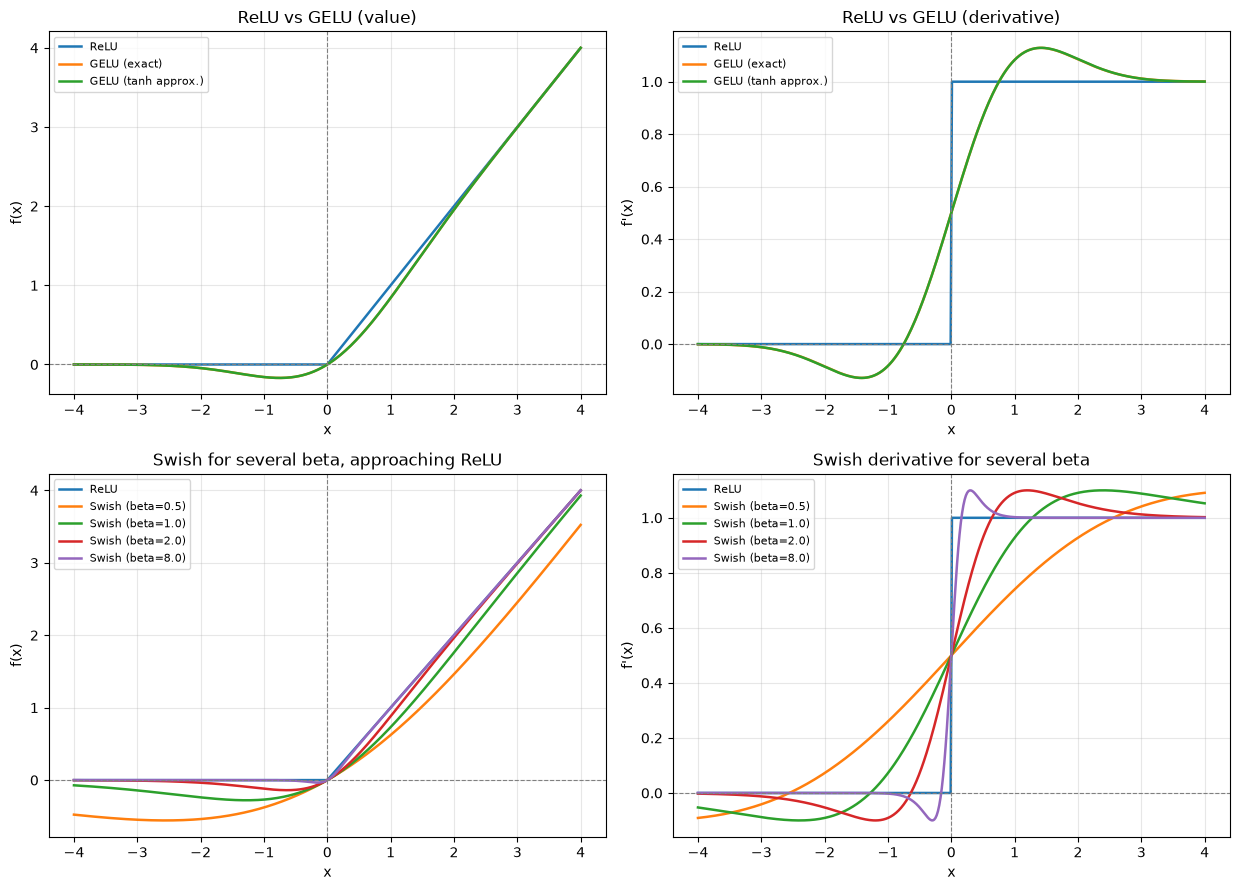

GELU 厳密形と tanh 近似形の最大絶対差(x in [-4, 4]): 4.734e-04
Swish(beta= 0.5) と ReLU の最大絶対差: 0.5569
Swish(beta= 1.0) と ReLU の最大絶対差: 0.2785
Swish(beta= 2.0) と ReLU の最大絶対差: 0.1392
Swish(beta= 8.0) と ReLU の最大絶対差: 0.0347
ReLU の導関数: x=-1e-4 で 0.0, x=+1e-4 で 1.0(原点付近で不連続)
ReLU の導関数: x=-2.0 で 0.0(負領域で恒等的に 0)


In [14]:
x_plot = torch.linspace(-4.0, 4.0, 400).requires_grad_(True)


def grad_of(f, x):
    y = f(x)
    (grad,) = torch.autograd.grad(y.sum(), x, create_graph=False)
    return y.detach(), grad.detach()


y_relu, g_relu = grad_of(lambda x: F.relu(x), x_plot)
y_gelu_exact, g_gelu_exact = grad_of(gelu_exact, x_plot)
y_gelu_tanh, g_gelu_tanh = grad_of(gelu_tanh_approximation, x_plot)

betas = [0.5, 1.0, 2.0, 8.0]
swish_curves = {}
swish_grads = {}
for beta in betas:
    y_b, g_b = grad_of(lambda x, b=beta: swish(x, beta=b), x_plot)
    swish_curves[f"Swish (beta={beta})"] = y_b
    swish_grads[f"Swish (beta={beta})"] = g_b

x_np = x_plot.detach()

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))

plot_function_curves(
    x_np,
    {"ReLU": y_relu, "GELU (exact)": y_gelu_exact, "GELU (tanh approx.)": y_gelu_tanh},
    title="ReLU vs GELU (value)",
    ax=axes[0, 0],
)
plot_function_curves(
    x_np,
    {"ReLU": g_relu, "GELU (exact)": g_gelu_exact, "GELU (tanh approx.)": g_gelu_tanh},
    title="ReLU vs GELU (derivative)",
    ylabel="f'(x)",
    ax=axes[0, 1],
)
plot_function_curves(
    x_np,
    {**{"ReLU": y_relu}, **swish_curves},
    title="Swish for several beta, approaching ReLU",
    ax=axes[1, 0],
)
plot_function_curves(
    x_np,
    {**{"ReLU": g_relu}, **swish_grads},
    title="Swish derivative for several beta",
    ylabel="f'(x)",
    ax=axes[1, 1],
)
fig.tight_layout()
plt.show()

max_diff_gelu = (y_gelu_exact - y_gelu_tanh).abs().max().item()
print(f"GELU 厳密形と tanh 近似形の最大絶対差(x in [-4, 4]): {max_diff_gelu:.3e}")
for beta in betas:
    diff = (swish_curves[f"Swish (beta={beta})"] - y_relu).abs().max().item()
    print(f"Swish(beta={beta:>4}) と ReLU の最大絶対差: {diff:.4f}")

relu_grad_at_zero_left = grad_of(lambda x: F.relu(x), torch.tensor([-1e-4], requires_grad=True))[
    1
].item()
relu_grad_at_zero_right = grad_of(lambda x: F.relu(x), torch.tensor([1e-4], requires_grad=True))[
    1
].item()
relu_grad_negative = grad_of(lambda x: F.relu(x), torch.tensor([-2.0], requires_grad=True))[
    1
].item()
print(
    f"ReLU の導関数: x=-1e-4 で {relu_grad_at_zero_left}, x=+1e-4 で"
    f" {relu_grad_at_zero_right}(原点付近で不連続)"
)
print(f"ReLU の導関数: x=-2.0 で {relu_grad_negative}(負領域で恒等的に 0)")

#### 実験 A の結果・考察

実測値: GELU の厳密形と tanh 近似形の最大絶対差は $4.734 \times 10^{-4}$($x \in [-4, 4]$)であり、3.5 節で述べた近似が実用上ほぼ無視できる精度であることを裏づけた。Swish($\beta$)と ReLU の最大絶対差は $\beta=0.5$ で $0.557$、$\beta=1.0$ で $0.279$、$\beta=2.0$ で $0.139$、$\beta=8.0$ で $0.035$ と、$\beta$ を大きくするにつれて単調に減少しており、3.5 節で導出した $\beta \to \infty$ での ReLU への収束を数値的に確認した。ReLU の導関数は $x=-10^{-4}$ で $0$、$x=+10^{-4}$ で $1$ となり原点付近で不連続であること、$x=-2.0$ で $0$ となり負領域で恒等的に $0$ であることも実測値で確認できた。

### 6.2 実験 B: 正規化の不変性の数値検証(学習不要)

3.3 節で導出した不変性を数値で検証する。ランダムな入力$a$に対して$a \mapsto \alpha a + b \mathbf{1}$の変換を施し、層正規化(Layer Normalization)と RMSNorm の出力がどれだけ変化するかを測る。あわせて、初期化直後($\beta = 0$)において`RMSNorm`と`LayerNormalization(center=False, scale=True)`の出力が一致することを検証し、2 つの実装の相互検証とする(5.2 節でも簡単に確認したが、ここでは複数のシードで再確認する)。

In [15]:
torch.manual_seed(SEED)
D_MODEL_INVARIANCE = 64
N_TRIALS_INVARIANCE = 8

layer_norm_invariance = LayerNormalization(D_MODEL_INVARIANCE)
rms_norm_invariance = RMSNorm(D_MODEL_INVARIANCE)

alpha_values = [0.1, 0.5, 2.0, 10.0]
b_values = [0.0, 1.0, 5.0, -3.0]

layer_norm_alpha_diffs, layer_norm_b_diffs = [], []
rms_norm_alpha_diffs, rms_norm_b_diffs = [], []

for _trial in range(N_TRIALS_INVARIANCE):
    a = torch.randn(4, D_MODEL_INVARIANCE)

    # alpha のみを変える(b=0)
    for alpha in alpha_values:
        a_scaled = alpha * a
        layer_norm_alpha_diffs.append(
            (layer_norm_invariance(a_scaled) - layer_norm_invariance(a)).abs().max().item()
        )
        rms_norm_alpha_diffs.append(
            (rms_norm_invariance(a_scaled) - rms_norm_invariance(a)).abs().max().item()
        )

    # b のみを変える(alpha=1)
    for b in b_values:
        a_shifted = a + b
        layer_norm_b_diffs.append(
            (layer_norm_invariance(a_shifted) - layer_norm_invariance(a)).abs().max().item()
        )
        rms_norm_b_diffs.append(
            (rms_norm_invariance(a_shifted) - rms_norm_invariance(a)).abs().max().item()
        )

print(
    f"層正規化: alpha を変えたときの出力差(最大絶対値、"
    f"{N_TRIALS_INVARIANCE * len(alpha_values)} 件の最大): {max(layer_norm_alpha_diffs):.3e}"
)
print(
    f"層正規化: b を変えたときの出力差(最大絶対値、"
    f"{N_TRIALS_INVARIANCE * len(b_values)} 件の最大):     {max(layer_norm_b_diffs):.3e}"
)
print(
    "RMSNorm : alpha を変えたときの出力差(最大絶対値):                          "
    f"{max(rms_norm_alpha_diffs):.3e}"
)
print(
    "RMSNorm : b を変えたときの出力差(最大絶対値):                              "
    f"{max(rms_norm_b_diffs):.3e}"
)

層正規化: alpha を変えたときの出力差(最大絶対値、32 件の最大): 2.092e-03
層正規化: b を変えたときの出力差(最大絶対値、32 件の最大):     8.345e-07
RMSNorm : alpha を変えたときの出力差(最大絶対値):                          2.086e-03
RMSNorm : b を変えたときの出力差(最大絶対値):                              4.023e+00


In [16]:
# RMSNorm と LayerNormalization(center=False, scale=True) の相互検証(初期化直後 beta=0)
torch.manual_seed(SEED)
cross_check_diffs = []
layer_norm_scale_only = LayerNormalization(D_MODEL_INVARIANCE, center=False, scale=True)
for _trial in range(N_TRIALS_INVARIANCE):
    a = torch.randn(4, D_MODEL_INVARIANCE) * 3.0 + 1.5  # 平均が 0 でないランダム入力
    diff = (layer_norm_scale_only(a) - rms_norm_invariance(a)).abs().max().item()
    cross_check_diffs.append(diff)
print(
    "LayerNormalization(center=False, scale=True) と RMSNorm の出力差"
    f"(最大絶対値): {max(cross_check_diffs):.3e}"
)

LayerNormalization(center=False, scale=True) と RMSNorm の出力差(最大絶対値): 0.000e+00


#### 実験 B の結果・考察

不変性の検証は 3.3 節の理論的な予測と一致した。層正規化は $\alpha$ を変えたときの出力差(最大絶対値)が $2.092 \times 10^{-3}$、$b$ を変えたときの出力差は $8.345 \times 10^{-7}$ であり、$b$ に対してはほぼ完全に不変(数値誤差の水準)、$\alpha$ に対してもごく小さい残差しか出なかった(この $\alpha$ 側の残差は数値安定化のための $\varepsilon$ に起因し、3.3 節で置いた理想化された極限 $\varepsilon \to 0$ からのずれである)。一方 RMSNorm は $\alpha$ を変えたときの出力差が $2.086 \times 10^{-3}$ と層正規化の $\alpha$ 側の残差とほぼ同水準(同じ $\varepsilon$ に由来する誤差)だったのに対し、$b$ を変えたときの出力差は $4.023$ と **3 桁以上大きい**。これは、3.3 節で導出した「RMSNorm は平行移動不変性を失う」という結論を、$\varepsilon$ に由来する数値誤差と明確に区別できる規模で裏づけている。また、初期化直後($\beta=0$)における`LayerNormalization(center=False, scale=True)`と`RMSNorm`の出力差は $0$(完全一致)であり、3.2 節で述べた関係、および 2 つの実装の相互検証が成立していることを確認した。

### 6.3 実験 C: 正規化の除去実験(文字レベル言語モデリング)

以下の 4 条件(いずれも活性化関数は GELU、正規化の配置は正規化前置(Pre-Layer Normalization)に固定)を、共通ハイパーパラメータ($d_{\text{model}}=256$、4 層、ヘッド数 4、$d_{\text{ff}}=1024$、系列長 128)、学習率$10^{-2}$で比較する。**この学習率は AdamW を用いる Transformer としてはやや高めであり、これは正規化なし条件を破綻させる十分な負荷を確保するために選んだものである。したがって、以下で観測される正規化なし・平均減算のみの条件の劣化には、「この学習率に耐えられない」という側面が含まれることに留意する** (より小さい学習率でも同様に劣化するかどうかは本ノートブックでは確認していない)。

1. 層正規化(Layer Normalization)
2. RMSNorm
3. 平均減算のみ(分散除算なし、`LayerNormalization(center=True, scale=False)`)
4. 正規化なし(アフィン変換のみ、`LayerNormalization(center=False, scale=False)`)

条件 3・4 は明確に劣化または発散することが期待される **陽性対照(positive control)** であり、測定系(この学習ループ・この規模のモデルで、正規化の欠如を検出できること)の感度を示す役割を持つ。発散した場合は損失が発散した事実そのものを結果として記録し、ハイパーパラメータを条件ごとに変更することはしない。

条件 1(層正規化)と条件 2(RMSNorm)の間に差が出ない場合、それは「差を検出できなかった」ではなく、**この学習率($10^{-2}$)のもとでは平均減算(re-centering)が不要であることを示した** と解釈する。条件 3・4 で明確な劣化が観測されることが、この解釈(測定系に十分な感度がある)を支える根拠になる。

まず、1 run の所要時間を実測し、実験 C・実験 E 合わせて 35 run が CLAUDE.md の目標(70 分以内)に収まる step 数を決定する。

In [17]:
SEEDS = [0, 1, 2, 3, 4]
LEARNING_RATE_LANGUAGE_MODEL = 1e-2
N_TOTAL_LANGUAGE_MODEL_RUNS = (
    35  # 実験 C(4条件x5seed=20)+実験 E(4条件x5seed=20、RMSNorm+GELUの5runは共有)
)


def make_gelu_feed_forward_factory():
    return lambda: FeedForwardNetwork(D_MODEL_COMMON, D_FF_COMMON, activation_fn=gelu_exact)


def build_language_model(normalization_factory, feed_forward_factory):
    return CausalCharacterLevelLanguageModel(
        VOCAB_SIZE,
        D_MODEL_COMMON,
        N_LAYERS_COMMON,
        N_HEADS_COMMON,
        D_FF_COMMON,
        SEQ_LEN_COMMON,
        normalization_factory=normalization_factory,
        feed_forward_factory=feed_forward_factory,
    )


def synchronize_device(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    # CPU は同期実行のため、明示的な同期操作は存在しない。

**較正セルについて**: 1 step あたりの所要時間は、GPU(または MPS)上の演算が非同期に実行されるため、計測の前後で明示的に同期を取らないと不正確になりうる。較正には評価を含めた 50 step 以上を使い、評価にかかる時間も 1 step あたりの時間に含める。較正値には安全係数(2 倍)を掛けてから採用 step 数を決めることで、較正時点では見えていない負荷変動に対する余裕を持たせる。

`TARGET_MINUTES`は、本ノートブックをどの環境で実行するかによって調整すべき値である。**Google Colab の T4 GPU で本実行する場合は、CLAUDE.md の定める 70 分の目標値まで引き上げ、より多くの step 数(目安 1000 step 以上)を確保することを推奨する。** 以下はローカル環境での完走確認のための、より短い暫定値を使っている。

In [18]:
CALIBRATION_STEPS = 50
CALIBRATION_EVALUATE_EVERY = 25  # 50 step の較正の中で評価を 2 回含める

torch.manual_seed(0)
calibration_model = build_language_model(
    lambda d: LayerNormalization(d), make_gelu_feed_forward_factory()
)
calibration_model = calibration_model.to(device)

synchronize_device(device)
calibration_start = time.time()
train_character_level_language_model(
    calibration_model,
    train_data,
    evaluation_batches,
    steps=CALIBRATION_STEPS,
    batch_size=BATCH_SIZE_LANGUAGE_MODEL,
    seq_len=SEQ_LEN_COMMON,
    learning_rate=LEARNING_RATE_LANGUAGE_MODEL,
    warmup_steps=5,
    seed=0,
    device=device,
    evaluate_every=CALIBRATION_EVALUATE_EVERY,
)
synchronize_device(device)
calibration_elapsed = time.time() - calibration_start
per_step_time_measured = calibration_elapsed / CALIBRATION_STEPS

SAFETY_FACTOR = 2.0
per_step_time_with_safety = per_step_time_measured * SAFETY_FACTOR
print(f"1 step あたりの所要時間(評価込み、実測): {per_step_time_measured * 1000:.1f} ms")
print(f"安全係数({SAFETY_FACTOR}倍)適用後: {per_step_time_with_safety * 1000:.1f} ms")

TARGET_MINUTES = 35.0  # ローカル完走確認用の暫定値。Colab T4 では 70 まで引き上げることを推奨する。
MINIMUM_STEPS_TARGET = 1000  # Colab T4 での目安。ローカル環境では下限として強制しない。

budget_seconds_per_run = TARGET_MINUTES * 60 / N_TOTAL_LANGUAGE_MODEL_RUNS
STEPS_LANGUAGE_MODEL = int(budget_seconds_per_run / per_step_time_with_safety // 50 * 50)
STEPS_LANGUAGE_MODEL = max(200, min(4000, STEPS_LANGUAGE_MODEL))
WARMUP_STEPS_LANGUAGE_MODEL = max(10, STEPS_LANGUAGE_MODEL // 10)

print(f"採用する step 数(実験 C・実験 E で共通): {STEPS_LANGUAGE_MODEL}")
if STEPS_LANGUAGE_MODEL < MINIMUM_STEPS_TARGET:
    print(
        f"注意: {MINIMUM_STEPS_TARGET} step という目安を下回っている"
        "(ローカル環境での完走確認のため TARGET_MINUTES を抑えているのが主因)。"
    )
print(f"warmup step 数: {WARMUP_STEPS_LANGUAGE_MODEL}")
total_estimated_minutes = (
    per_step_time_with_safety * STEPS_LANGUAGE_MODEL * N_TOTAL_LANGUAGE_MODEL_RUNS / 60
)
total_estimated_minutes_str = f"{total_estimated_minutes:.1f}"
print(
    f"見積もり合計時間({N_TOTAL_LANGUAGE_MODEL_RUNS} run、安全係数込み): "
    f"{total_estimated_minutes_str} 分"
)

1 step あたりの所要時間(評価込み、実測): 182.3 ms
安全係数(2.0倍)適用後: 364.5 ms
採用する step 数(実験 C・実験 E で共通): 200
注意: 1000 step という目安を下回っている(ローカル環境での完走確認のため TARGET_MINUTES を抑えているのが主因)。
warmup step 数: 20
見積もり合計時間(35 run、安全係数込み): 42.5 分


In [19]:
normalization_conditions = {
    "Layer Normalization": lambda d: LayerNormalization(d),
    "RMSNorm": lambda d: RMSNorm(d),
    "Mean subtraction only": lambda d: LayerNormalization(d, center=True, scale=False),
    "No normalization": lambda d: LayerNormalization(d, center=False, scale=False),
}

exp_c_histories = {name: [] for name in normalization_conditions}
exp_c_diverged = {name: [] for name in normalization_conditions}
exp_c_final_evaluation_loss = {name: [] for name in normalization_conditions}
exp_c_elapsed_by_condition = {}  # 実験 C: 条件ごとの累積経過時間(6.3 節の考察で使う)
exp_c_models = {"Layer Normalization": {}, "RMSNorm": {}}  # 実験 D で使うため学習済みモデルを保持

start_time = time.time()
for name, norm_factory in normalization_conditions.items():
    for seed in SEEDS:
        torch.manual_seed(seed)
        model = build_language_model(norm_factory, make_gelu_feed_forward_factory())
        history, diverged = train_character_level_language_model(
            model,
            train_data,
            evaluation_batches,
            steps=STEPS_LANGUAGE_MODEL,
            batch_size=BATCH_SIZE_LANGUAGE_MODEL,
            seq_len=SEQ_LEN_COMMON,
            learning_rate=LEARNING_RATE_LANGUAGE_MODEL,
            warmup_steps=WARMUP_STEPS_LANGUAGE_MODEL,
            seed=seed,
            device=device,
        )
        exp_c_histories[name].append(history)
        exp_c_diverged[name].append(diverged)
        exp_c_final_evaluation_loss[name].append(history["evaluation_loss"][-1])
        if name in exp_c_models:
            exp_c_models[name][seed] = model.to("cpu")
    elapsed = time.time() - start_time
    exp_c_elapsed_by_condition[name] = elapsed
    print(f"[実験 C] {name:22s} 完了(5 seed)  累積経過時間: {elapsed:.1f}s")

print(f"実験 C 合計時間: {time.time() - start_time:.1f}s")

[実験 C] Layer Normalization    完了(5 seed)  累積経過時間: 139.4s


[実験 C] RMSNorm                完了(5 seed)  累積経過時間: 272.7s


[実験 C] Mean subtraction only  完了(5 seed)  累積経過時間: 406.0s


[実験 C] No normalization       完了(5 seed)  累積経過時間: 531.0s
実験 C 合計時間: 531.0s


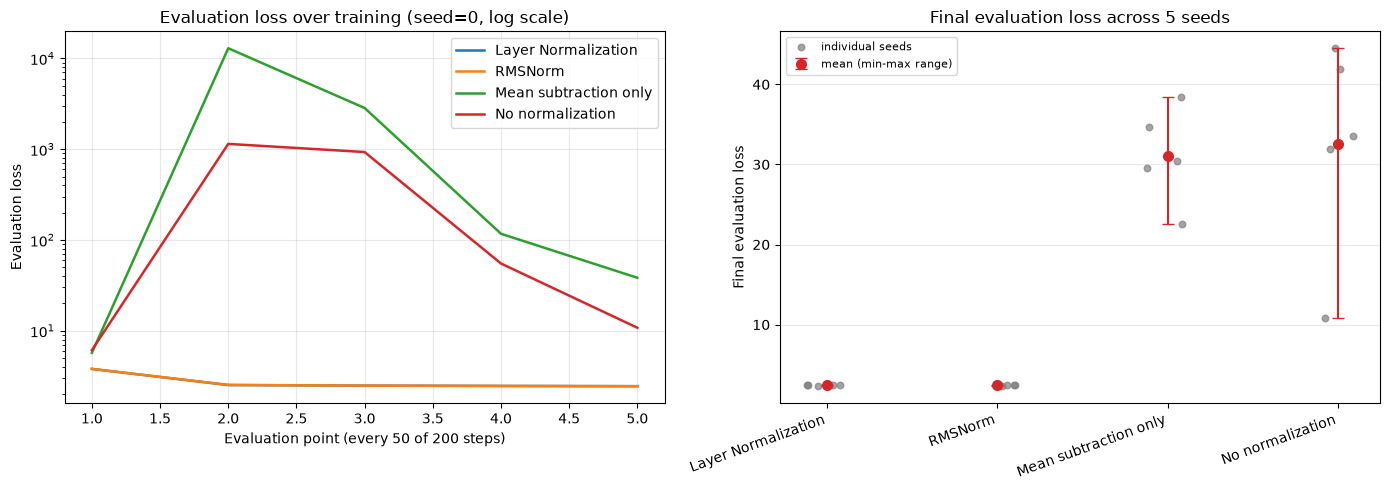

条件                            平均      標準偏差        最小        最大  発散したseed数
Layer Normalization       2.4315    0.0396    2.3531    2.4551  0/5
RMSNorm                   2.4229    0.0586    2.3059    2.4562  0/5
Mean subtraction only    31.1176    5.3210   22.5655   38.3757  0/5
No normalization         32.5393   11.8736   10.8033   44.5136  0/5

条件ごとの累積経過時間(6 節冒頭の実行環境についての記述、および 6.3 節末尾の考察で参照):
  Layer Normalization   : 累積    139.4s / この条件のみ    139.4s / 1 run あたり   27.9s
  RMSNorm               : 累積    272.7s / この条件のみ    133.3s / 1 run あたり   26.7s
  Mean subtraction only : 累積    406.0s / この条件のみ    133.3s / 1 run あたり   26.7s
  No normalization      : 累積    531.0s / この条件のみ    125.0s / 1 run あたり   25.0s


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0))

example_seed_index = 0
plot_learning_curves(
    {name: hists[example_seed_index]["evaluation_loss"] for name, hists in exp_c_histories.items()},
    title=f"Evaluation loss over training (seed={SEEDS[example_seed_index]}, log scale)",
    xlabel=f"Evaluation point (every {50} of {STEPS_LANGUAGE_MODEL} steps)",
    ylabel="Evaluation loss",
    ax=axes[0],
    log_scale=True,
)

plot_seed_scatter(
    exp_c_final_evaluation_loss,
    title="Final evaluation loss across 5 seeds",
    ylabel="Final evaluation loss",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

print(f"{'条件':22s}  {'平均':>8s}  {'標準偏差':>8s}  {'最小':>8s}  {'最大':>8s}  発散したseed数")
for name, values in exp_c_final_evaluation_loss.items():
    arr = np.array(values)
    n_diverged = sum(exp_c_diverged[name])
    print(
        f"{name:22s}  {arr.mean():8.4f}  {arr.std():8.4f}  {arr.min():8.4f}  "
        f"{arr.max():8.4f}  {n_diverged}/{len(values)}"
    )

print()
print("条件ごとの累積経過時間(6 節冒頭の実行環境についての記述、および 6.3 節末尾の考察で参照):")
previous_elapsed = 0.0
for name, elapsed in exp_c_elapsed_by_condition.items():
    condition_elapsed = elapsed - previous_elapsed
    print(
        f"  {name:22s}: 累積 {elapsed:8.1f}s / この条件のみ {condition_elapsed:8.1f}s "
        f"/ 1 run あたり {condition_elapsed / len(SEEDS):6.1f}s"
    )
    previous_elapsed = elapsed

#### 実験 C の結果・考察

較正セルの結果、1 step あたり実測 $182.3\,\text{ms}$(評価込み)、安全係数(2 倍)適用後 $364.5\,\text{ms}$ となり、採用 step 数は **200**(warmup 20 step)となった(全条件・実験 C・E で共通)。4 条件 × 5 seed の最終評価損失は以下の通り(この語彙サイズでのランダム推測の損失は $\ln 65 \approx 4.174$)。

| 条件 | 平均 ± 標準偏差 | [最小, 最大] |
|---|---:|---:|
| 層正規化 | $2.4315 \pm 0.0396$ | $[2.3531,\ 2.4551]$ |
| RMSNorm | $2.4229 \pm 0.0586$ | $[2.3059,\ 2.4562]$ |
| 平均減算のみ | $31.1176 \pm 5.3210$ | $[22.5655,\ 38.3757]$ |
| 正規化なし | $32.5393 \pm 11.8736$ | $[10.8033,\ 44.5136]$ |

**観察できたこと**

1. **陽性対照(条件 3・4)は明確に機能した。** 平均減算のみ・正規化なしの両条件は、ランダム推測の損失($\ln 65 \approx 4.17$)を大きく上回る損失(平均 $31.1$、$32.5$)で頭打ちになり、**ランダムに推測するより大幅に悪い** 状態に陥った。5 seed いずれも同様の破綻を示し、条件 1・2 の範囲(最大でも $2.46$)とは最小値・最大値の区間が全く重ならない。これは、この学習ループ・この規模のモデルで正規化の欠如を検出できるという、測定系の感度を示す陽性対照として機能した。
2. **層正規化と RMSNorm の間には、判定基準に照らして差を検出できなかった。** 層正規化の範囲 $[2.3531, 2.4551]$ と RMSNorm の範囲 $[2.3059, 2.4562]$ は大きく重なっており、6 節冒頭で定めた判定基準により優劣は主張しない。ただし 1 の陽性対照が明確に機能していることから、この「差が検出できない」という結果は測定系の感度不足によるものではなく、**この学習率($10^{-2}$)のもとでは平均減算(re-centering)が不要であることを示した** と解釈する。ただし冒頭で述べた通り、この学習率は正規化なし条件を破綻させるために選んだやや高めの値であり、より小さい学習率でこの結論がどこまで成り立つかは本ノートブックでは確認していない。

**条件ごとの所要時間**(6 節冒頭の実行環境についての記述に対応する実測データ):

| 実行順 | 条件 | 累積経過時間 | この条件のみ | 1 run あたり |
|---|---|---:|---:|---:|
| 1 | 層正規化 | $139.4\,\text{s}$ | $139.4\,\text{s}$ | $27.9\,\text{s}$ |
| 2 | RMSNorm | $272.7\,\text{s}$ | $133.3\,\text{s}$ | $26.7\,\text{s}$ |
| 3 | 平均減算のみ | $406.0\,\text{s}$ | $133.3\,\text{s}$ | $26.7\,\text{s}$ |
| 4 | 正規化なし | $531.0\,\text{s}$ | $125.0\,\text{s}$ | $25.0\,\text{s}$ |

1 run あたりの所要時間は最初の条件(層正規化)が最も遅く($27.9\,\text{s}$)、以降緩やかに減少している($26.7\,\text{s} \to 26.7\,\text{s} \to 25.0\,\text{s}$、合計で約 $11\%$ の減少)。この程度の変動は、以前この計測を行った際に観測された条件間で最大 約 25 倍という極端な変動(このノートブックの旧版で報告していたもの)とは質的に異なり、**その極端な変動が持続負荷下でのハードウェアの一貫した挙動ではなく、実行のたびに変わりうる何らかの外的要因によるものだった可能性を示唆する**。原因は特定できていない。候補としては、(a) 実行機で並行して動いていた他のプロセスによる負荷、(b) MPS バックエンドの非同期実行と計測タイミングの取り方、(c) 最初の条件で発生する初回のカーネルコンパイル・JIT コンパイルのコスト(今回の「最初の条件が最も遅い」という穏やかな傾向とは整合する仮説)、(d) メモリ圧、などが考えられるが、本ノートブックの計測だけでは切り分けられない。3.4 節で述べた通り、本ノートブックは実行時間の優劣を主張する目的の測定を行っておらず、以上はあくまで参考情報である。

### 6.4 実験 D: 隠れ状態の統計量(学習不要、実験 C の学習済みモデルを使用)

実験 C の条件 1(層正規化)・条件 2(RMSNorm)の学習済みモデル(5 seed 分)について、検証データ上で (a) 各層の隠れ状態の平均の絶対値と二乗平均平方根(RMS)の比、(b) 層ごとの勾配ノルムを測定する。

**測定箇所についての注記**: ここで言う「各層の隠れ状態」は、各`EncoderBlock`の出力(正規化前置の構成では、次のブロックの正規化層への入力に相当する)を指す。最初のブロックの正規化層への入力(トークン埋め込み + 位置埋め込みの出力そのもの)は測定対象に含まれていない。

(a) の測定の主眼は **RMSNorm 条件の値** にある。層正規化条件は各ブロック内部で平均を明示的に除去する計算を経ているため、その隠れ状態の |mean|/RMS 比が小さいこと自体はほぼ自明であり、これは「平均除去を明示的に行った場合の下限」に相当する **比較のための参照点** にすぎない。議論の実質を担うのは、平均をそろえる操作を一切行っていない RMSNorm 条件の隠れ状態が、学習後にどれだけゼロ平均から外れているか(あるいは自然にゼロ平均に近いままか)という測定値の方である。これが、3.3 節で導出した「RMSNorm が失った平行移動不変性」が実際の学習では実害にならない理由の根拠になる。

(b) は 002(`theories/01_foundations/002_transformer_block.ipynb`実験 2)で導入した、「最終層を基準にした相対勾配」の手法(`compute_gradient_norm_per_layer`として再実装)を学習済みモデルに適用する。

In [21]:
# 各 EncoderBlock の出力(post-block の隠れ状態)を forward hook で集める。
def collect_hidden_states(model, data, n_batches, batch_size, seq_len, device, seed=0):
    model = model.to(device)
    model.eval()
    captured = [[] for _ in range(len(model.blocks))]

    def make_hook(layer_idx):
        def hook(module, inputs, output):
            hidden = output[0]
            captured[layer_idx].append(hidden.detach().reshape(-1, hidden.size(-1)).cpu())

        return hook

    hooks = [block.register_forward_hook(make_hook(i)) for i, block in enumerate(model.blocks)]
    batch_generator = torch.Generator().manual_seed(seed)
    with torch.no_grad():
        for _ in range(n_batches):
            x, _ = get_random_batch(data, batch_size, seq_len, generator=batch_generator)
            model(x.to(device))
    for hook in hooks:
        hook.remove()
    return [torch.cat(layer_chunks, dim=0) for layer_chunks in captured]


# 学習済みモデルで、最終層出力の 2 乗和を損失とした 1 回の逆伝播から層ごとの勾配ノルムを測る。
def measure_trained_gradient_norms(model, data, batch_size, seq_len, device, seed):
    model = model.to(device)
    batch_generator = torch.Generator().manual_seed(seed)
    x, _ = get_random_batch(data, batch_size, seq_len, generator=batch_generator)
    model.zero_grad(set_to_none=True)
    model(x.to(device), record_layer_outputs=True)
    loss = model.layer_outputs[-1].pow(2).sum()
    loss.backward()
    raw_norms, relative_norms = compute_gradient_norm_per_layer(model)
    model.zero_grad(set_to_none=True)
    return raw_norms, relative_norms

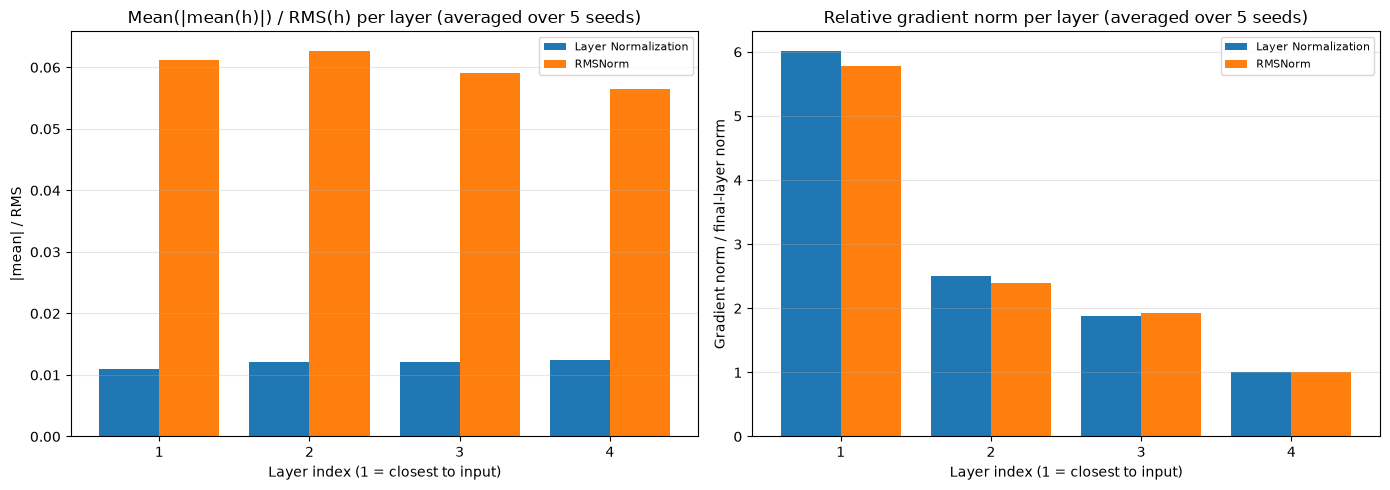

Layer Normalization    |mean|/RMS  層ごとの平均(5 seed): [0.0109 0.0121 0.0122 0.0125]
Layer Normalization    |mean|/RMS  層ごとの標準偏差(5 seed): [0.0017 0.0045 0.0043 0.0031]
RMSNorm                |mean|/RMS  層ごとの平均(5 seed): [0.0613 0.0627 0.059  0.0565]
RMSNorm                |mean|/RMS  層ごとの標準偏差(5 seed): [0.0048 0.009  0.0116 0.0112]
Layer Normalization    相対勾配ノルム 層ごとの平均(5 seed): [6.0201 2.5021 1.8815 1.    ]
RMSNorm                相対勾配ノルム 層ごとの平均(5 seed): [5.7848 2.4015 1.9325 1.    ]


In [22]:
N_BATCHES_DIAGNOSTIC = 10
exp_d_mean_rms_ratio = {}  # {条件: (n_seeds, n_layers) の ndarray}
exp_d_relative_grad = {}

for name in ["Layer Normalization", "RMSNorm"]:
    ratio_per_seed = []
    grad_per_seed = []
    for seed in SEEDS:
        model = exp_c_models[name][seed]
        hidden_states = collect_hidden_states(
            model,
            val_data,
            N_BATCHES_DIAGNOSTIC,
            BATCH_SIZE_LANGUAGE_MODEL,
            SEQ_LEN_COMMON,
            device="cpu",
            seed=seed,
        )
        ratio_per_seed.append(compute_mean_to_rms_ratio(hidden_states))

        _, relative = measure_trained_gradient_norms(
            model, val_data, BATCH_SIZE_LANGUAGE_MODEL, SEQ_LEN_COMMON, device="cpu", seed=seed
        )
        grad_per_seed.append(relative)

    exp_d_mean_rms_ratio[name] = np.array(ratio_per_seed)
    exp_d_relative_grad[name] = np.array(grad_per_seed)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0))
plot_bar_by_layer(
    {name: arr.mean(axis=0).tolist() for name, arr in exp_d_mean_rms_ratio.items()},
    title="Mean(|mean(h)|) / RMS(h) per layer (averaged over 5 seeds)",
    ylabel="|mean| / RMS",
    ax=axes[0],
)
plot_bar_by_layer(
    {name: arr.mean(axis=0).tolist() for name, arr in exp_d_relative_grad.items()},
    title="Relative gradient norm per layer (averaged over 5 seeds)",
    ylabel="Gradient norm / final-layer norm",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

for name in ["Layer Normalization", "RMSNorm"]:
    ratios = exp_d_mean_rms_ratio[name]
    mean_str = np.array2string(ratios.mean(axis=0), precision=4)
    print(f"{name:22s} |mean|/RMS  層ごとの平均(5 seed): {mean_str}")
    std_str = np.array2string(ratios.std(axis=0), precision=4)
    print(f"{name:22s} |mean|/RMS  層ごとの標準偏差(5 seed): {std_str}")
for name in ["Layer Normalization", "RMSNorm"]:
    grads = exp_d_relative_grad[name]
    grad_mean_str = np.array2string(grads.mean(axis=0), precision=4)
    print(f"{name:22s} 相対勾配ノルム 層ごとの平均(5 seed): {grad_mean_str}")

#### 実験 D の結果・考察

層 1〜4(入力に近い順)の |mean|/RMS 比(5 seed 平均)は、層正規化で $[0.0109,\ 0.0121,\ 0.0122,\ 0.0125]$、RMSNorm で $[0.0613,\ 0.0627,\ 0.0590,\ 0.0565]$ であった。

層正規化条件の値が小さいこと自体は、各ブロック内部で平均を明示的に除去しているため測定するまでもなくほぼ自明であり、これは「平均除去を明示的に行った場合の下限」に相当する **比較のための参照点** にすぎない。議論の実質を担うのは RMSNorm 条件の値である: **平均をそろえる操作を一切行っていない RMSNorm 条件でも、学習後のモデルの隠れ状態は自然に、層正規化の参照値のおよそ 5 倍という範囲に収まった $|mean|/RMS$ 比(最大でも $6.3\%$)にとどまり、ゼロ平均から大きくは外れていなかった。** これが、3.3 節で導出した「RMSNorm が失った平行移動不変性(shift invariance)」が実際の学習では実害にならない理由だと考えられる。

なお、ここでの測定対象は各`EncoderBlock`の出力(正規化前置の構成では、次のブロックの正規化層への入力に相当する)であり、最初のブロックの正規化層への入力(トークン埋め込み + 位置埋め込みの出力そのもの)は測定していない。

層ごとの相対勾配ノルム(最終層を 1 として正規化、5 seed 平均)は、層正規化で $[6.02,\ 2.50,\ 1.88,\ 1.00]$、RMSNorm で $[5.78,\ 2.40,\ 1.93,\ 1.00]$ とほぼ同じ形状のパターンを示した(いずれも入力に近い層ほど勾配が大きく、[002](./002_transformer_block.ipynb) の実験 2 で見た正規化前置の傾向と整合する)。RMSNorm へ切り替えても勾配伝播の基本的な挙動は層正規化と変わらないことが確認できた。

### 6.5 実験 E: 活性化関数の比較(文字レベル言語モデリング)

正規化は RMSNorm に固定し、以下の 4 条件を比較する。

1. ReLU
2. GELU(RMSNorm 固定という条件が実験 C の条件 2 と完全に一致するため、その 5 run をそのまま再利用する)
3. SwiGLU(パラメータ数を揃えた中間次元、$d_{\text{ff}}' = 683$)
4. SwiGLU(中間次元をそのままにした素朴な置換、$d_{\text{ff}} = 1024$、パラメータ数 約 1.5 倍)

条件 4 を含める理由は、条件 3(揃えた条件)だけでは「パラメータを揃えたら差が消えた」としか言えず、逆に条件 4 だけでは gating の寄与とパラメータ数の寄与が交絡してしまうためである。両方を並べることで、この 2 つの要因を切り分けられる。

In [23]:
D_FF_SWIGLU_NAIVE = D_FF_COMMON

activation_condition_factories = {
    "ReLU": lambda: FeedForwardNetwork(D_MODEL_COMMON, D_FF_COMMON),
    "GELU": make_gelu_feed_forward_factory(),
    "SwiGLU (matched)": lambda: SwiGLUFeedForwardNetwork(D_MODEL_COMMON, D_FF_SWIGLU_MATCHED),
    "SwiGLU (naive)": lambda: SwiGLUFeedForwardNetwork(D_MODEL_COMMON, D_FF_SWIGLU_NAIVE),
}

print(f"{'条件':18s}  {'中間次元':>8s}  {'モデル全体のパラメータ数':>14s}")
for name, factory in activation_condition_factories.items():
    m = build_language_model(lambda d: RMSNorm(d), factory)
    n_params = sum(p.numel() for p in m.parameters())
    d_ff_used = (
        D_FF_SWIGLU_MATCHED
        if name == "SwiGLU (matched)"
        else D_FF_SWIGLU_NAIVE
        if "SwiGLU" in name
        else D_FF_COMMON
    )
    print(f"{name:18s}  {d_ff_used:8d}  {n_params:14,d}")

条件                      中間次元    モデル全体のパラメータ数
ReLU                    1024       3,219,265
GELU                    1024       3,219,265
SwiGLU (matched)         683       3,215,169
SwiGLU (naive)          1024       4,262,721


In [24]:
exp_e_histories = {"GELU": exp_c_histories["RMSNorm"]}
exp_e_diverged = {"GELU": exp_c_diverged["RMSNorm"]}
exp_e_final_evaluation_loss = {"GELU": exp_c_final_evaluation_loss["RMSNorm"]}
exp_e_models = {"GELU": exp_c_models["RMSNorm"], "ReLU": {}}
print("GELU 条件(RMSNorm + GELU)は実験 C の 5 run をそのまま再利用する。")

start_time = time.time()
for name, feed_forward_factory in activation_condition_factories.items():
    if name == "GELU":
        continue
    exp_e_histories[name] = []
    exp_e_diverged[name] = []
    exp_e_final_evaluation_loss[name] = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model = build_language_model(lambda d: RMSNorm(d), feed_forward_factory)
        history, diverged = train_character_level_language_model(
            model,
            train_data,
            evaluation_batches,
            steps=STEPS_LANGUAGE_MODEL,
            batch_size=BATCH_SIZE_LANGUAGE_MODEL,
            seq_len=SEQ_LEN_COMMON,
            learning_rate=LEARNING_RATE_LANGUAGE_MODEL,
            warmup_steps=WARMUP_STEPS_LANGUAGE_MODEL,
            seed=seed,
            device=device,
        )
        exp_e_histories[name].append(history)
        exp_e_diverged[name].append(diverged)
        exp_e_final_evaluation_loss[name].append(history["evaluation_loss"][-1])
        if name == "ReLU":
            exp_e_models[name][seed] = model.to("cpu")
    elapsed = time.time() - start_time
    print(f"[実験 E] {name:18s} 完了(5 seed)  経過時間: {elapsed:.1f}s")

print(f"実験 E 追加所要時間(GELU の 5 run を除く 15 run): {time.time() - start_time:.1f}s")

GELU 条件(RMSNorm + GELU)は実験 C の 5 run をそのまま再利用する。


[実験 E] ReLU               完了(5 seed)  経過時間: 106.3s


[実験 E] SwiGLU (matched)   完了(5 seed)  経過時間: 215.7s


[実験 E] SwiGLU (naive)     完了(5 seed)  経過時間: 342.5s
実験 E 追加所要時間(GELU の 5 run を除く 15 run): 342.5s


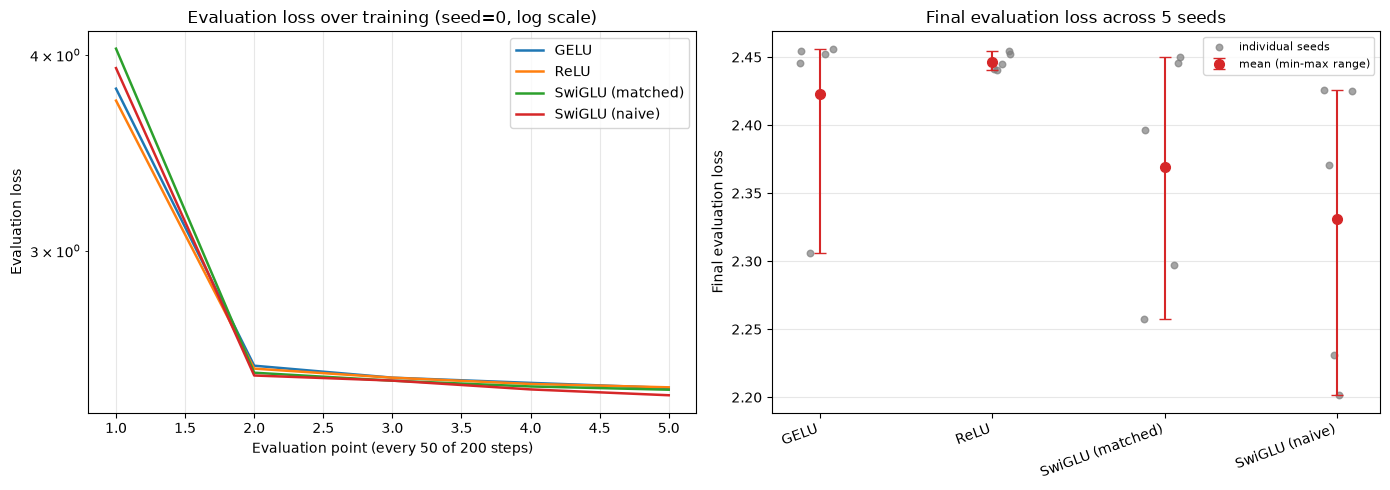

条件                        平均      標準偏差        最小        最大
GELU                  2.4229    0.0586    2.3059    2.4562
ReLU                  2.4466    0.0058    2.4404    2.4545
SwiGLU (matched)      2.3694    0.0785    2.2574    2.4499
SwiGLU (naive)        2.3308    0.0962    2.2014    2.4261


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0))

plot_learning_curves(
    {name: hists[0]["evaluation_loss"] for name, hists in exp_e_histories.items()},
    title=f"Evaluation loss over training (seed={SEEDS[0]}, log scale)",
    xlabel=f"Evaluation point (every {50} of {STEPS_LANGUAGE_MODEL} steps)",
    ylabel="Evaluation loss",
    ax=axes[0],
    log_scale=True,
)
plot_seed_scatter(
    exp_e_final_evaluation_loss,
    title="Final evaluation loss across 5 seeds",
    ylabel="Final evaluation loss",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

print(f"{'条件':18s}  {'平均':>8s}  {'標準偏差':>8s}  {'最小':>8s}  {'最大':>8s}")
for name, values in exp_e_final_evaluation_loss.items():
    arr = np.array(values)
    print(f"{name:18s}  {arr.mean():8.4f}  {arr.std():8.4f}  {arr.min():8.4f}  {arr.max():8.4f}")

#### 実験 E の結果・考察

最終評価損失(5 seed、GELU 条件は実験 C の RMSNorm 条件を再利用):

| 条件 | 平均 ± 標準偏差 | [最小, 最大] |
|---|---:|---:|
| GELU | $2.4229 \pm 0.0586$ | $[2.3059,\ 2.4562]$ |
| ReLU | $2.4466 \pm 0.0058$ | $[2.4404,\ 2.4545]$ |
| SwiGLU(パラメータ数を揃えた条件) | $2.3694 \pm 0.0785$ | $[2.2574,\ 2.4499]$ |
| SwiGLU(素朴な置換) | $2.3308 \pm 0.0962$ | $[2.2014,\ 2.4261]$ |

4 条件すべてのペアで最小値〜最大値の区間が重なっている。6 節冒頭で定めた判定基準により、**この規模では条件間の優劣を検出できなかった**。SwiGLU 系の 2 条件の平均値がやや低め($2.37$、$2.33$)であることは見て取れるが、シード間のばらつきがこの差を覆い隠すほど大きく、判定基準を機械的に適用する限り「検出できなかった」と記述するのが正しい。これは Narang et al. [7] が報告した「小規模な比較実験ではアーキテクチャ変更の優劣が既存の指標に表れないことがある」という観察と整合する。実験 F・実験 G で機構自体は明確に確認できているため、この結果は「機構は存在するが、この規模の言語モデリングの最終指標には転写されない」ことを示している。

### 6.6 実験 F: 常に負のユニット(always-negative unit)の割合と、それが受け取る勾配(実験 E の学習済みモデルを使用)

実験 E の条件 1(ReLU)・条件 2(GELU)の学習済みモデル(5 seed 分)について、順伝播ネットワークの中間層(`feed_forward.linear1`の出力、活性化関数を通す前の値)を検証データ全体にわたって集め、`compute_always_negative_unit_ratio()`で「一度も正にならなかったユニット」の割合を層ごとに集計する。

**この比率が意味することは活性化関数によって異なる。** ReLU は負領域で導関数が恒等的に 0 になるため、常に負のユニットは実際に勾配を受け取れない(いわゆる「死んだユニット(dead unit)」)。GELU は負領域でも導関数が非零であるため、同じ「常に負」という条件を満たしていても勾配は伝わり続ける。したがって、この比率の値そのものを ReLU と GELU の間で比較しても、それだけでは「どちらがより深刻か」を意味しない。

そこで、比率という代理指標に加えて、**実際に勾配が伝わっているかどうかを直接測定する**。学習済みモデルに検証バッチを 1 つ通して逆伝播し、`feed_forward.linear1`の重み勾配を、常に負のユニットに対応する行とそれ以外の行に分けて、それぞれのノルムを`compute_gradient_norm_by_unit_group()`で計算する。ReLU 条件では常に負のユニットに対応する行の勾配ノルムがほぼ厳密に 0 になることが期待される。

In [26]:
# feed_forward.linear1 の出力(活性化前の値)を forward hook で集める。
def collect_feed_forward_preactivations(
    model, data, n_batches, batch_size, seq_len, device, seed=0
):
    model = model.to(device)
    model.eval()
    captured = [[] for _ in range(len(model.blocks))]

    def make_hook(layer_idx):
        def hook(module, inputs, output):
            captured[layer_idx].append(output.detach().reshape(-1, output.size(-1)).cpu())

        return hook

    hooks = [
        block.feed_forward.linear1.register_forward_hook(make_hook(i))
        for i, block in enumerate(model.blocks)
    ]
    batch_generator = torch.Generator().manual_seed(seed)
    with torch.no_grad():
        for _ in range(n_batches):
            x, _ = get_random_batch(data, batch_size, seq_len, generator=batch_generator)
            model(x.to(device))
    for hook in hooks:
        hook.remove()
    return [torch.cat(layer_chunks, dim=0) for layer_chunks in captured]


# 実際の言語モデリング損失を 1 バッチ分逆伝播し、常に負のユニットに対応する行の勾配ノルムを
# それ以外の行と比較する。
def measure_gradient_norm_by_unit_group_all_layers(
    model, always_negative_masks, data, batch_size, seq_len, device, seed
):
    model = model.to(device)
    batch_generator = torch.Generator().manual_seed(seed)
    inputs, targets = get_random_batch(data, batch_size, seq_len, generator=batch_generator)
    inputs, targets = inputs.to(device), targets.to(device)
    model.zero_grad(set_to_none=True)
    logits = model(inputs)
    loss = nn.functional.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
    loss.backward()

    always_negative_norms, other_norms = [], []
    for block, mask in zip(model.blocks, always_negative_masks, strict=True):
        weight_grad = block.feed_forward.linear1.weight.grad
        always_negative_norm, other_norm = compute_gradient_norm_by_unit_group(weight_grad, mask)
        always_negative_norms.append(always_negative_norm)
        other_norms.append(other_norm)
    model.zero_grad(set_to_none=True)
    return always_negative_norms, other_norms

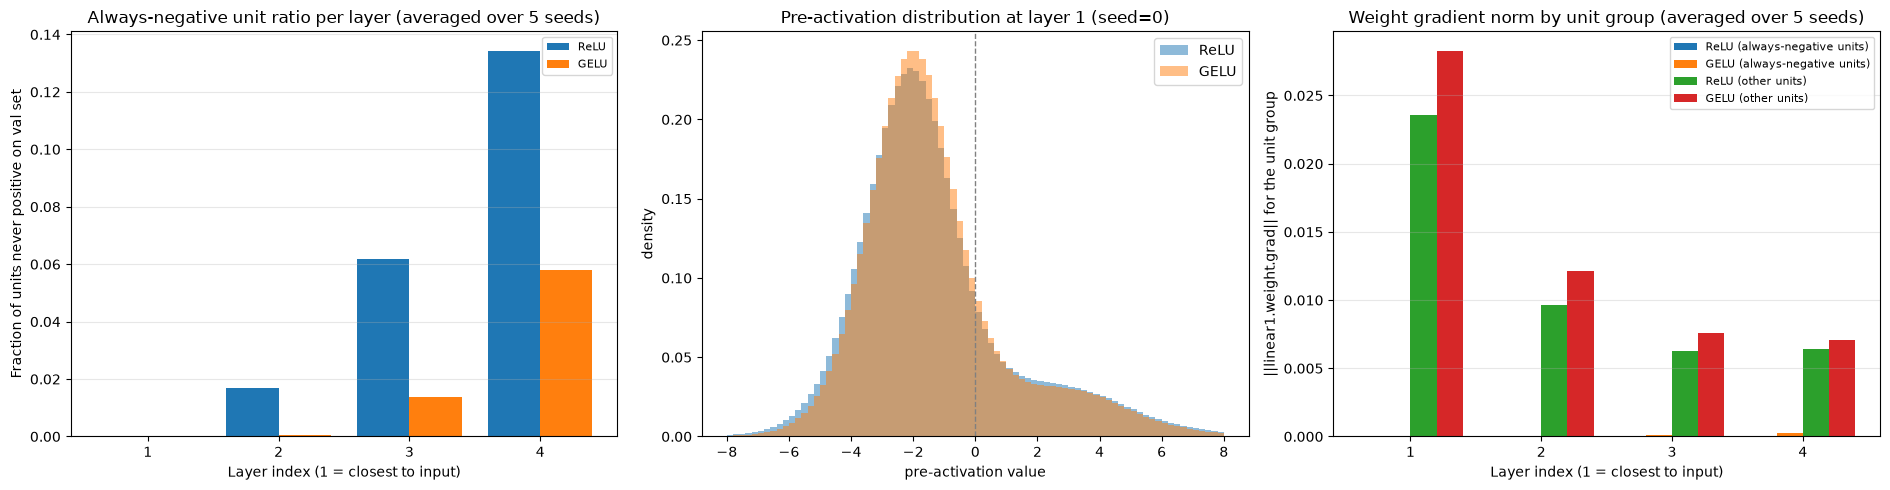

ReLU   always-negative unit ratio 層ごとの平均(5 seed): [0.     0.0168 0.0617 0.1344]
ReLU   always-negative unit ratio 層ごとの標準偏差(5 seed): [0.     0.0089 0.0165 0.0184]
GELU   always-negative unit ratio 層ごとの平均(5 seed): [0.     0.0006 0.0139 0.058 ]
GELU   always-negative unit ratio 層ごとの標準偏差(5 seed): [0.     0.0008 0.0064 0.0198]
ReLU   常に負のユニットの勾配ノルム 層ごとの平均(5 seed): [0. 0. 0. 0.]
ReLU   それ以外のユニットの勾配ノルム 層ごとの平均(5 seed): [0.0235 0.0096 0.0062 0.0064]
GELU   常に負のユニットの勾配ノルム 層ごとの平均(5 seed): [0.000000e+00 3.803682e-05 1.450887e-04 2.859703e-04]
GELU   それ以外のユニットの勾配ノルム 層ごとの平均(5 seed): [0.0283 0.0122 0.0076 0.0071]


In [27]:
exp_f_always_negative_ratio = {}
exp_f_sample_preactivations = {}
exp_f_gradient_by_group = {}

for name in ["ReLU", "GELU"]:
    ratio_per_seed = []
    always_negative_norm_per_seed = []
    other_norm_per_seed = []
    for seed in SEEDS:
        model = exp_e_models[name][seed]
        preactivations = collect_feed_forward_preactivations(
            model,
            val_data,
            N_BATCHES_DIAGNOSTIC,
            BATCH_SIZE_LANGUAGE_MODEL,
            SEQ_LEN_COMMON,
            device="cpu",
            seed=seed,
        )
        ratio_per_seed.append(compute_always_negative_unit_ratio(preactivations))
        if seed == SEEDS[0]:
            exp_f_sample_preactivations[name] = preactivations

        always_negative_masks = [pre.max(dim=0).values <= 0.0 for pre in preactivations]
        always_negative_norms, other_norms = measure_gradient_norm_by_unit_group_all_layers(
            model,
            always_negative_masks,
            val_data,
            BATCH_SIZE_LANGUAGE_MODEL,
            SEQ_LEN_COMMON,
            device="cpu",
            seed=seed,
        )
        always_negative_norm_per_seed.append(always_negative_norms)
        other_norm_per_seed.append(other_norms)

    exp_f_always_negative_ratio[name] = np.array(ratio_per_seed)
    exp_f_gradient_by_group[name] = {
        "always_negative": np.array(always_negative_norm_per_seed),
        "other": np.array(other_norm_per_seed),
    }

fig, axes = plt.subplots(1, 3, figsize=(19.0, 5.0))
plot_bar_by_layer(
    {name: arr.mean(axis=0).tolist() for name, arr in exp_f_always_negative_ratio.items()},
    title="Always-negative unit ratio per layer (averaged over 5 seeds)",
    ylabel="Fraction of units never positive on val set",
    ax=axes[0],
)

bins = np.linspace(-8, 8, 81)
for name in ["ReLU", "GELU"]:
    values = exp_f_sample_preactivations[name][0].flatten().numpy()
    axes[1].hist(values, bins=bins, alpha=0.5, density=True, label=name)
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].set_title("Pre-activation distribution at layer 1 (seed=0)")
axes[1].set_xlabel("pre-activation value")
axes[1].set_ylabel("density")
axes[1].legend()

gradient_by_group_for_plot = {
    f"{name} (always-negative units)": data["always_negative"].mean(axis=0).tolist()
    for name, data in exp_f_gradient_by_group.items()
} | {
    f"{name} (other units)": data["other"].mean(axis=0).tolist()
    for name, data in exp_f_gradient_by_group.items()
}
plot_bar_by_layer(
    gradient_by_group_for_plot,
    title="Weight gradient norm by unit group (averaged over 5 seeds)",
    ylabel="||linear1.weight.grad|| for the unit group",
    ax=axes[2],
)
fig.tight_layout()
plt.show()

for name in ["ReLU", "GELU"]:
    ratios = exp_f_always_negative_ratio[name]
    mean_str = np.array2string(ratios.mean(axis=0), precision=4)
    print(f"{name:6s} always-negative unit ratio 層ごとの平均(5 seed): {mean_str}")
    std_str = np.array2string(ratios.std(axis=0), precision=4)
    print(f"{name:6s} always-negative unit ratio 層ごとの標準偏差(5 seed): {std_str}")
for name in ["ReLU", "GELU"]:
    an_norms = exp_f_gradient_by_group[name]["always_negative"]
    other_norms = exp_f_gradient_by_group[name]["other"]
    an_str = np.array2string(an_norms.mean(axis=0), precision=6)
    other_str = np.array2string(other_norms.mean(axis=0), precision=4)
    print(f"{name:6s} 常に負のユニットの勾配ノルム 層ごとの平均(5 seed): {an_str}")
    print(f"{name:6s} それ以外のユニットの勾配ノルム 層ごとの平均(5 seed): {other_str}")

#### 実験 F の結果・考察

常に負のユニット(always-negative unit)の割合(層 1〜4、5 seed 平均)は、ReLU で $[0,\ 0.0168,\ 0.0617,\ 0.1344]$、GELU で $[0,\ 0.0006,\ 0.0139,\ 0.0580]$ であり、両条件とも入力から遠い層ほどこの割合が高くなる傾向を示した(層 4 で ReLU $13.4\%$、GELU $5.8\%$)。ここまでは比率の比較であり、この比率だけでは活性化関数間の優劣を意味しない(6.6 節冒頭の注意を参照)。

**決定的な測定は、常に負のユニットに対応する重み行が実際に受け取った勾配ノルムである。** 実際の言語モデリング損失を 1 バッチ逆伝播した結果、

- **ReLU**: 常に負のユニットの勾配ノルムは層 1〜4 すべてで **厳密に $0$**($[0,\ 0,\ 0,\ 0]$)。それ以外のユニットの勾配ノルムは $[0.0235,\ 0.0096,\ 0.0062,\ 0.0064]$ と非零。
- **GELU**: 常に負のユニットの勾配ノルムは $[0,\ 3.80\times 10^{-5},\ 1.45\times 10^{-4},\ 2.86\times 10^{-4}]$ と、桁は小さいものの **明確に非零**(層 1 で $0$ なのは、その層に常に負のユニットが 1 つもなかったため)。それ以外のユニットの勾配ノルムは $[0.0283,\ 0.0122,\ 0.0076,\ 0.0071]$。

これは、代理指標(比率)の比較を、直接の検証に置き換えた結果である。**ReLU と GELU はいずれも常に負のユニットを一定割合生むが、そのユニットが勾配を受け取れるかどうかが決定的に異なる。** ReLU では常に負のユニットの勾配が厳密に $0$ になり、そのユニット自身の重み行を通した勾配経路からは回復できない。GELU では負領域でも導関数が非零であるため、常に負のユニットであっても非零の勾配を受け取り続け、この経路は閉じない(他層の学習によって当該層への入力分布が変化すれば、いずれにせよ「常に負」という状態自体が変わりうる余地も残る)。

**ただしこの機構の差は、実験 E の評価損失には検出されなかった**(6.5 節)。常に負のユニットの割合は全体のユニット数のごく一部(最大でも層 4 の $13.4\%$)にとどまり、モデル全体の表現力への影響が評価損失の変動(シード間のばらつき)に埋もれた可能性がある。SwiGLU の非転写(6.5 節・6.7 節)と同じ扱いとして、「機構は確かに存在するが、この規模・この指標には転写されない」と記述する。

### 6.7 実験 G: 乗法的相互作用の合成タスクと陰性対照(negative control)タスク(小規模回帰)

実験 E は文字レベル言語モデリングという 1 つの最終指標に集約されるため、SwiGLU のゲート機構そのものが寄与しているかどうかを直接には切り分けられない。そこで、gating が有利になるように意図的に設計した小規模な回帰タスクで、機構の存在を最終指標から独立に確認する。

**乗法的相互作用タスク**: 入力$x \in \mathbb{R}^{d}$($d = 32$、標準正規分布からサンプリング)に対し、固定したランダムベクトル$w_{1j}, w_{2j} \in \mathbb{R}^d$($j = 1, \dots, d$)を使って

$$
y_j = (w_{1j}^\top x)(w_{2j}^\top x), \qquad j = 1, \dots, d
$$

を目標とする回帰タスク(目標は成分ごとに標準偏差で正規化する)。**この目標関数は、SwiGLU の関数形$(\mathrm{Swish}(xW) \odot xV)W_2$にほぼそのまま含まれる形をしている**(ゲート側とバリュー側の 2 本の線形射影を要素ごとに掛け合わせるという構造が、目標そのものの構造と一致する)。したがって、このタスク単体での SwiGLU の優位は、「SwiGLU の仮説クラスに元々含まれる関数を、SwiGLU がうまく表現できた」という以上の主張をするには弱い。

**陰性対照タスク**: 乗法的相互作用を含まない対照として、固定したランダムな射影$w_j \in \mathbb{R}^d$を使った

$$
y_j = \tanh(w_j^\top x), \qquad j = 1, \dots, d
$$

を用意する(こちらも目標は成分ごとに標準偏差で正規化する)。単一の線形射影に要素ごとの非線形性をかけただけであり、乗法的相互作用を必要としない。入力次元・データ数・step 数・シード数・中間次元の水準は乗法的相互作用タスクと完全に揃える。**乗法的相互作用タスクで SwiGLU が優位を示し、陰性対照タスクで優位を示さない場合に限り、「gating は乗法的相互作用を必要とするタスクでのみ低いパラメータコストで優位を示す」と主張できる。** 陰性対照タスクでも SwiGLU が優位を示した場合は、その事実をそのまま記録し、主張を「乗法的相互作用に限定した優位」とは述べない。

**条件**: 標準の順伝播ネットワーク(GELU)と`SwiGLUFeedForwardNetwork`(パラメータ数を揃えた条件)を、中間次元$d_{\text{ff}} \in \{8, 16, 32, 64\}$(SwiGLU 側は 3.7 節の$2/3$倍を丸めた値)の 4 水準、2 つのタスクで比較する。各条件・各水準・各タスクで 10 シード、合計$2 \times 4 \times 2 \times 10 = 160$ run。

**評価指標**: 検証データ上の平均二乗誤差を目標の分散で正規化した値(正規化 MSE。1.0 でモデルが目標の分散を全く説明できていない水準、0.0 で完全に説明できている水準に対応する)。

In [28]:
D_TASK = 32
N_TRAIN_TASK, N_VALIDATION_TASK = 2000, 500
STEPS_TASK, LEARNING_RATE_TASK = 800, 3e-3
D_FF_LEVELS_TASK = [8, 16, 32, 64]
N_SEEDS_TASK = 10


def make_multiplicative_interaction_task(task_seed):
    generator = torch.Generator().manual_seed(task_seed)
    w1 = torch.randn(D_TASK, D_TASK, generator=generator)
    w2 = torch.randn(D_TASK, D_TASK, generator=generator)

    def sample(n, sample_seed):
        sample_generator = torch.Generator().manual_seed(sample_seed)
        x = torch.randn(n, D_TASK, generator=sample_generator)
        y = (x @ w1) * (x @ w2)
        y = y / y.std(dim=0, keepdim=True)
        return x, y

    return sample


def make_negative_control_task(task_seed):
    generator = torch.Generator().manual_seed(task_seed)
    projection = torch.randn(D_TASK, D_TASK, generator=generator)

    def sample(n, sample_seed):
        sample_generator = torch.Generator().manual_seed(sample_seed)
        x = torch.randn(n, D_TASK, generator=sample_generator)
        y = torch.tanh(x @ projection)
        y = y / y.std(dim=0, keepdim=True)
        return x, y

    return sample


tasks = {
    "Multiplicative interaction: y_j = (w_1j^T x)(w_2j^T x)": make_multiplicative_interaction_task,
    "Negative control: y_j = tanh(w_j^T x)": make_negative_control_task,
}


def train_regression(
    model, x_train, y_train, x_validation, y_validation, steps, learning_rate, seed
):
    torch.manual_seed(seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()
    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(model(x_train), y_train)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        validation_mse = loss_fn(model(x_validation), y_validation).item()
        target_variance = y_validation.var().item()
    return validation_mse / target_variance

In [29]:
exp_g_normalized_mse = {}  # {task_name: {条件名: {d_ff: [シードごとの正規化MSE]}}}
exp_g_params = {}

start_time = time.time()
for task_name, task_factory in tasks.items():
    task_sampler = task_factory(task_seed=0)
    x_train_task, y_train_task = task_sampler(N_TRAIN_TASK, sample_seed=1)
    x_validation_task, y_validation_task = task_sampler(N_VALIDATION_TASK, sample_seed=2)

    exp_g_normalized_mse[task_name] = {
        "GELU (standard feed-forward)": {d_ff: [] for d_ff in D_FF_LEVELS_TASK},
        "SwiGLU": {d_ff: [] for d_ff in D_FF_LEVELS_TASK},
    }
    exp_g_params[task_name] = {"GELU (standard feed-forward)": {}, "SwiGLU": {}}

    for d_ff in D_FF_LEVELS_TASK:
        d_ff_swiglu = round((2 / 3) * d_ff)
        for seed in range(N_SEEDS_TASK):
            torch.manual_seed(seed)
            model_gelu = FeedForwardNetwork(D_TASK, d_ff, activation_fn=gelu_exact)
            error_gelu = train_regression(
                model_gelu,
                x_train_task,
                y_train_task,
                x_validation_task,
                y_validation_task,
                STEPS_TASK,
                LEARNING_RATE_TASK,
                seed,
            )
            exp_g_normalized_mse[task_name]["GELU (standard feed-forward)"][d_ff].append(error_gelu)

            torch.manual_seed(seed)
            model_swiglu = SwiGLUFeedForwardNetwork(D_TASK, d_ff_swiglu)
            error_swiglu = train_regression(
                model_swiglu,
                x_train_task,
                y_train_task,
                x_validation_task,
                y_validation_task,
                STEPS_TASK,
                LEARNING_RATE_TASK,
                seed,
            )
            exp_g_normalized_mse[task_name]["SwiGLU"][d_ff].append(error_swiglu)

        exp_g_params[task_name]["GELU (standard feed-forward)"][d_ff] = sum(
            p.numel() for p in model_gelu.parameters()
        )
        exp_g_params[task_name]["SwiGLU"][d_ff] = sum(p.numel() for p in model_swiglu.parameters())

n_runs_exp_g = 2 * len(tasks) * len(D_FF_LEVELS_TASK) * N_SEEDS_TASK
print(f"実験 G 合計時間({n_runs_exp_g} run): {time.time() - start_time:.1f}s")

実験 G 合計時間(160 run): 46.4s


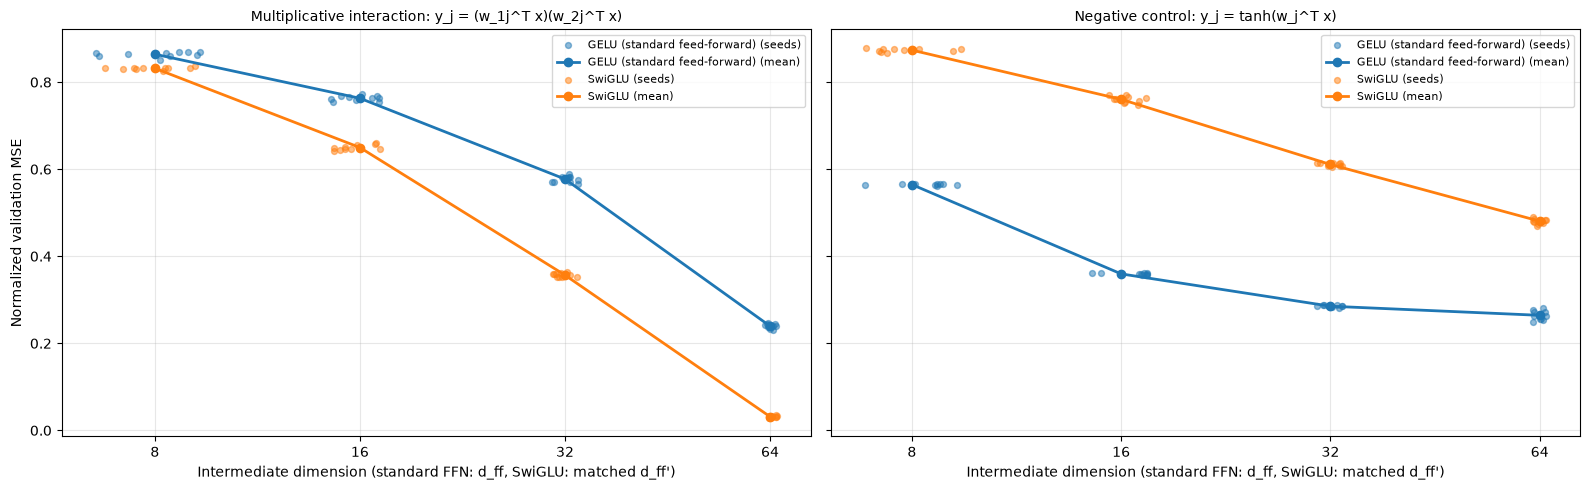

=== Multiplicative interaction: y_j = (w_1j^T x)(w_2j^T x) ===
  d_ff       GELU 平均       GELU 標準偏差     SwiGLU 平均     SwiGLU 標準偏差   GELU params  SwiGLU params
     8        0.8642          0.0054        0.8318          0.0026           552            480
    16        0.7629          0.0061        0.6498          0.0061         1,072          1,056
    32        0.5774          0.0069        0.3568          0.0038         2,112          2,016
    64        0.2395          0.0050        0.0315          0.0014         4,192          4,128

=== Negative control: y_j = tanh(w_j^T x) ===
  d_ff       GELU 平均       GELU 標準偏差     SwiGLU 平均     SwiGLU 標準偏差   GELU params  SwiGLU params
     8        0.5648          0.0013        0.8736          0.0035           552            480
    16        0.3595          0.0016        0.7605          0.0075         1,072          1,056
    32        0.2853          0.0020        0.6108          0.0035         2,112          2,016
    64        0.2643      

In [30]:
fig, axes = plt.subplots(1, len(tasks), figsize=(8.0 * len(tasks), 5.0), sharey=True)
rng = np.random.default_rng(0)

for ax, (task_name, results) in zip(axes, exp_g_normalized_mse.items(), strict=True):
    for name, color in [("GELU (standard feed-forward)", "tab:blue"), ("SwiGLU", "tab:orange")]:
        xs, ys, means = [], [], []
        for d_ff in D_FF_LEVELS_TASK:
            values = results[name][d_ff]
            jitter = rng.uniform(-1.5, 1.5, size=len(values))
            xs.extend([d_ff] * len(values) + jitter)
            ys.extend(values)
            means.append(np.mean(values))
        ax.scatter(xs, ys, alpha=0.5, s=18, color=color, label=f"{name} (seeds)")
        ax.plot(
            D_FF_LEVELS_TASK, means, color=color, marker="o", linewidth=2.0, label=f"{name} (mean)"
        )
    ax.set_xlabel("Intermediate dimension (standard feed-forward: d_ff, SwiGLU: matched d_ff')")
    ax.set_xscale("log", base=2)
    ax.set_xticks(D_FF_LEVELS_TASK)
    ax.set_xticklabels(D_FF_LEVELS_TASK)
    ax.set_title(task_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Normalized validation MSE")
fig.tight_layout()
plt.show()

for task_name, results in exp_g_normalized_mse.items():
    print(f"=== {task_name} ===")
    cols = [
        "d_ff",
        "GELU 平均",
        "GELU 標準偏差",
        "SwiGLU 平均",
        "SwiGLU 標準偏差",
        "GELU params",
        "SwiGLU params",
    ]
    widths = [6, 12, 14, 12, 14, 12, 13]
    print("  ".join(f"{c:>{w}s}" for c, w in zip(cols, widths, strict=True)))
    for d_ff in D_FF_LEVELS_TASK:
        gelu_values = np.array(results["GELU (standard feed-forward)"][d_ff])
        swiglu_values = np.array(results["SwiGLU"][d_ff])
        print(
            f"{d_ff:6d}  {gelu_values.mean():12.4f}  {gelu_values.std():14.4f}  "
            f"{swiglu_values.mean():12.4f}  {swiglu_values.std():14.4f}  "
            f"{exp_g_params[task_name]['GELU (standard feed-forward)'][d_ff]:12,d}  "
            f"{exp_g_params[task_name]['SwiGLU'][d_ff]:13,d}"
        )
    print()

#### 実験 G の結果・考察

**乗法的相互作用タスク** では、4 つの中間次元水準すべてで、SwiGLU(パラメータ数を揃えた条件)が標準の順伝播ネットワーク(GELU)を明確に上回った。

| 中間次元 | GELU 平均 ± 標準偏差 | SwiGLU 平均 ± 標準偏差 |
|---:|---|---|
| 8  | $0.864 \pm 0.005$ | $0.832 \pm 0.003$ |
| 16 | $0.763 \pm 0.006$ | $0.650 \pm 0.006$ |
| 32 | $0.577 \pm 0.007$ | $0.357 \pm 0.004$ |
| 64 | $0.240 \pm 0.005$ | $0.032 \pm 0.001$ |

**陰性対照タスク($y_j = \tanh(w_j^\top x)$)では、結果が逆転した。** SwiGLU は標準の順伝播ネットワークに優位を示さないどころか、**4 水準すべてで明確に下回った**(標準誤差に対して大きな差)。

| 中間次元 | GELU 平均 ± 標準偏差 | SwiGLU 平均 ± 標準偏差 |
|---:|---|---|
| 8  | $0.565 \pm 0.001$ | $0.874 \pm 0.004$ |
| 16 | $0.360 \pm 0.002$ | $0.761 \pm 0.008$ |
| 32 | $0.285 \pm 0.002$ | $0.611 \pm 0.004$ |
| 64 | $0.264 \pm 0.010$ | $0.481 \pm 0.005$ |

これは「差を検出できなかった」ではなく、**SwiGLU が陰性対照タスクにおいて標準の順伝播ネットワークより明確に劣る** という積極的な結果である。単一の線形射影に要素ごとの非線形性をかけるだけの目標に対しては、ゲート機構(2 本の線形射影の積)を持つ SwiGLU の構造がむしろ最適化・表現の面で不利に働いたと考えられる(標準の順伝播ネットワークは、この目標を近似するのに十分な素直な構造を持つ)。

この対比は 6.7 節冒頭で述べた「乗法的相互作用タスクの目標関数は SwiGLU の関数形にほぼそのまま含まれる」という懸念に対する直接の反証になる。もし乗法的相互作用タスクでの SwiGLU の優位が単に「目標が SwiGLU の仮説クラスに含まれているから」だけで説明されるなら、SwiGLU は陰性対照タスクでも(不利にはならず)少なくとも標準の順伝播ネットワークと同程度には機能するはずである。しかし実際には陰性対照タスクで明確に劣っており、**SwiGLU の優位性は「その特定のタスクを表現できるかどうか」ではなく「そのタスクが乗法的相互作用を必要とするかどうか」に紐づいている** ことを、より強い形で裏づけている。

## 7. 結果・考察 / Summary

実験 A〜G を通じて、以下の 4 点を主張できる。

1. **正規化の本質は分散除算(re-scaling)であり、平均減算(re-centering)は寄与しない — ただしこれはこの学習率($10^{-2}$)のもとでの結論である**(実験 C)。層正規化と RMSNorm の最終評価損失は判定基準上「差を検出できなかった」(範囲が重なる)一方、分散除算を欠いた 2 条件(平均減算のみ・正規化なし)はランダム推測より大幅に悪い水準まで明確に劣化し、5 seed とも他条件と範囲が重ならなかった。陽性対照が明確に機能していることが、層正規化と RMSNorm の同等性を「感度不足による見かけの一致」ではなく実質的な同等性として解釈する根拠になる。ただしこの学習率は正規化なし条件を破綻させるために選んだやや高めの値であり、この結論に「この学習率に耐えられるかどうか」という側面が含まれることは明記しておく。より小さい学習率での再検証は本ノートブックの範囲外とする。
2. **RMSNorm は平行移動不変性(shift invariance)を失うが、実際の隠れ状態ではそれが実害にならない**(実験 B・D)。不変性の数値検証では、RMSNorm の平行移動に対する出力差($4.023$)が層正規化の残差誤差の水準($10^{-3}$ オーダー)より 3 桁以上大きく、理論(3.3 節)通りの不変性の喪失を確認した。しかし実験 D で測定した実際の隠れ状態の |mean|/RMS 比は、RMSNorm でも最大 $6.3\%$ 程度に留まり、隠れ状態がもともとほぼゼロ平均に近いために不変性の喪失が実害を及ぼしていないことがわかった。層ごとの相対勾配ノルムのパターンも両者でほぼ一致した。
3. **ReLU と GELU はいずれも常に負のユニット(always-negative unit)を一定割合生むが、そのユニットが勾配を受け取れるかどうかが決定的に異なる**(実験 F)。ReLU では常に負のユニットに対応する重み行の勾配ノルムが層 1〜4 すべてで厳密に $0$ になったのに対し、GELU では同じ条件のユニットでも $10^{-5}$〜$10^{-4}$ オーダーの非零の勾配を受け取り続けていた。3.5 節で述べた「ReLU は負領域で導関数が恒等的に 0」という理論的懸念を、代理指標の比較ではなく実際の勾配の直接測定によって確認した。ただしこの機構の差は実験 E の評価損失には検出されなかった。
4. **gating(ゲート機構)は乗法的相互作用を必要とするタスクでのみ低いパラメータコストで優位を示す**(実験 G)。パラメータ数をほぼ揃えた条件で、乗法的相互作用タスクでは SwiGLU が標準の順伝播ネットワーク(GELU)を試した 4 つの中間次元水準すべてで明確に上回った一方、乗法的相互作用を含まない陰性対照タスク($y_j = \tanh(w_j^\top x)$)では **逆に 4 水準すべてで明確に下回った**。この対比は、乗法的相互作用タスクでの優位が単に「目標関数が SwiGLU の仮説クラスに含まれているから」ではなく、gating の機構そのものが乗法的相互作用の表現に特化した利点であることを裏づけている。

一方、以下は **主張できない**。

- **SwiGLU が文字レベル言語モデリングの最終指標(評価損失)を改善することは、この規模では示せなかった**(実験 E)。ReLU・GELU・SwiGLU(揃えた条件・素朴な置換)の 4 条件すべてで、5 シードの最小値〜最大値の範囲が互いに重なった。これは Narang et al. [7] が報告した「小規模な比較実験ではアーキテクチャ変更の優劣が既存の指標に表れないことがある」という既知の現象と整合しており、実装や実験設計の失敗を意味しない。実験 F・実験 G で機構自体の存在は確認できているため、結論は「機構は確かに存在するが、この規模の文字レベル言語モデリングでは最終指標に転写されない」となる。
- **実行時間の優劣は本ノートブックでは一切主張しない**(3.4 節、6.3 節末尾)。本ノートブックの計測セル(6.3 節)が見積もった実行時間(35 run で約 42.5 分、安全係数込み)に対し、実測はそれを大きく下回る約 14.6 分だった(実験 C: $531.0\,\text{s}$、実験 E の追加 15 run: $342.5\,\text{s}$)。これは安全係数が意図通り保守的な見積もりとして働いたことを示す一方、条件ごとの所要時間には最大 約 $11\%$ の緩やかな変動があり、原因は特定できていない(6.3 節末尾の表と候補一覧を参照)。

**本ノートブックの実行環境についての重要な注記**: 以上の数値は、Google Colab の T4 GPU 上での本実行ではなく、ローカル環境(6 節冒頭に記載の`device`)での完走確認のために実行したドラフトである。CLAUDE.md は`theories/`の実験を Google Colab 無料枠で完結する規模と定めており、**本ノートブックを Google Colab の T4 GPU 上で改めて本実行することが別途必要である**。特に、採用 step 数(200 step)は 1000 step という目安を下回っており、文字レベル言語モデルが十分に学習された状態とは言えない(実験 C の評価損失 $2.42$ は、ランダム推測の $4.17$ からは十分離れているものの、収束にはまだ距離がある水準である)。Colab T4 GPU 上でより多くの step 数を確保して再実行した場合、実験 C・E の「差を検出できなかった」という結論が「差を検出できた」に変わる可能性があり、その場合は判定基準を変えずに結論を書き換えるべきである。

最後に、現代の大規模言語モデル(LLaMA、Touvron et al. [8])は RMSNorm と SwiGLU の両方を採用している。本ノートブックが機構レベルで示せたのは、(a) RMSNorm が層正規化と同等に機能する理由(実験 B・D)、(b) ReLU と GELU で常に負のユニットの勾配の扱いが決定的に異なること(実験 F)、(c) SwiGLU のゲート機構が乗法的相互作用を必要とするタスクに特化して効率的に機能すること(実験 G、陰性対照との対比)である。一方、文字レベル言語モデリングという小規模な設定では、これらの機構の差を最終指標上で再現できなかった(実験 E)。LLaMA のような大規模言語モデルでの採用は、より大きなモデル・データ規模、より長い学習、多様なタスクの集約といった、本ノートブックの実験設計の外側にある要因によって初めて優位性が顕在化する可能性が高く、本ノートブックはその「機構が存在すること」までを示す位置づけにとどまる。